# The seaborn.objects interface (+ Properties, skim)

📄 Sources:
- https://seaborn.pydata.org/tutorial/objects_interface.html
- https://seaborn.pydata.org/tutorial/properties.html

`seaborn.objects` (since v0.12) is a **new, grammar-of-graphics style** interface: composable classes for transforming and plotting data, aiming to do everything without dropping to matplotlib.
It is still marked *experimental*. Know that it exists; **the function interface (notebooks 05-12) is what you'll use this month.**

In [1]:
import seaborn as sns
import matplotlib as mpl

tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins").dropna()
diamonds = sns.load_dataset("diamonds")
healthexp = sns.load_dataset("healthexp").sort_values(["Country", "Year"]).query("Year <= 2020")

print("seaborn", sns.__version__)

seaborn 0.13.2


## Specifying a plot and mapping data

Import convention:

In [2]:
import seaborn.objects as so

The main class is `Plot`. Create it, then call methods on it. A scatter plot:

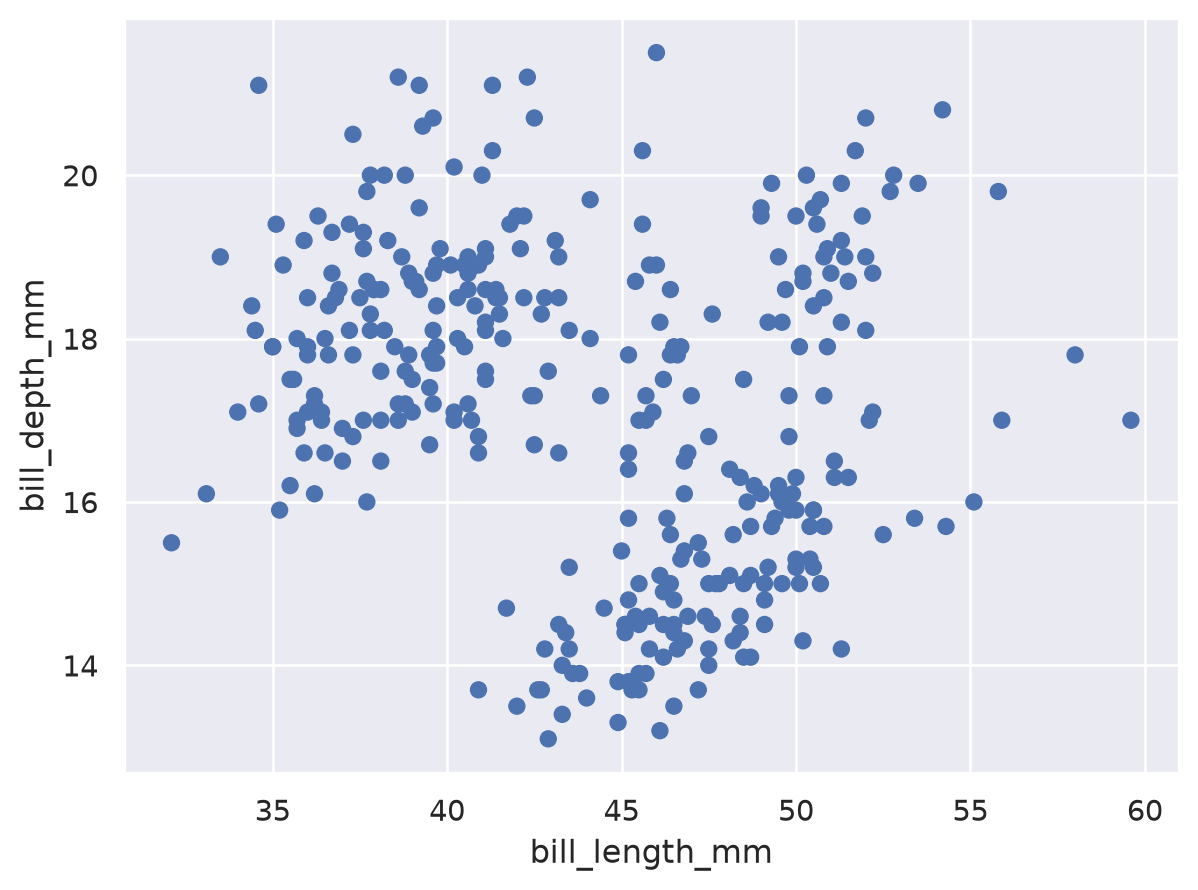

In [3]:
(
    so.Plot(penguins, x="bill_length_mm", y="bill_depth_mm")   # 1) data + which columns go where
    .add(so.Dot())                                             # 2) the graphical element (a "Mark")
)

Different order from the function API: **data assignments first**, then the graphical element.

### Setting properties

`Dot` is a **Mark**. Marks have properties you can set directly:

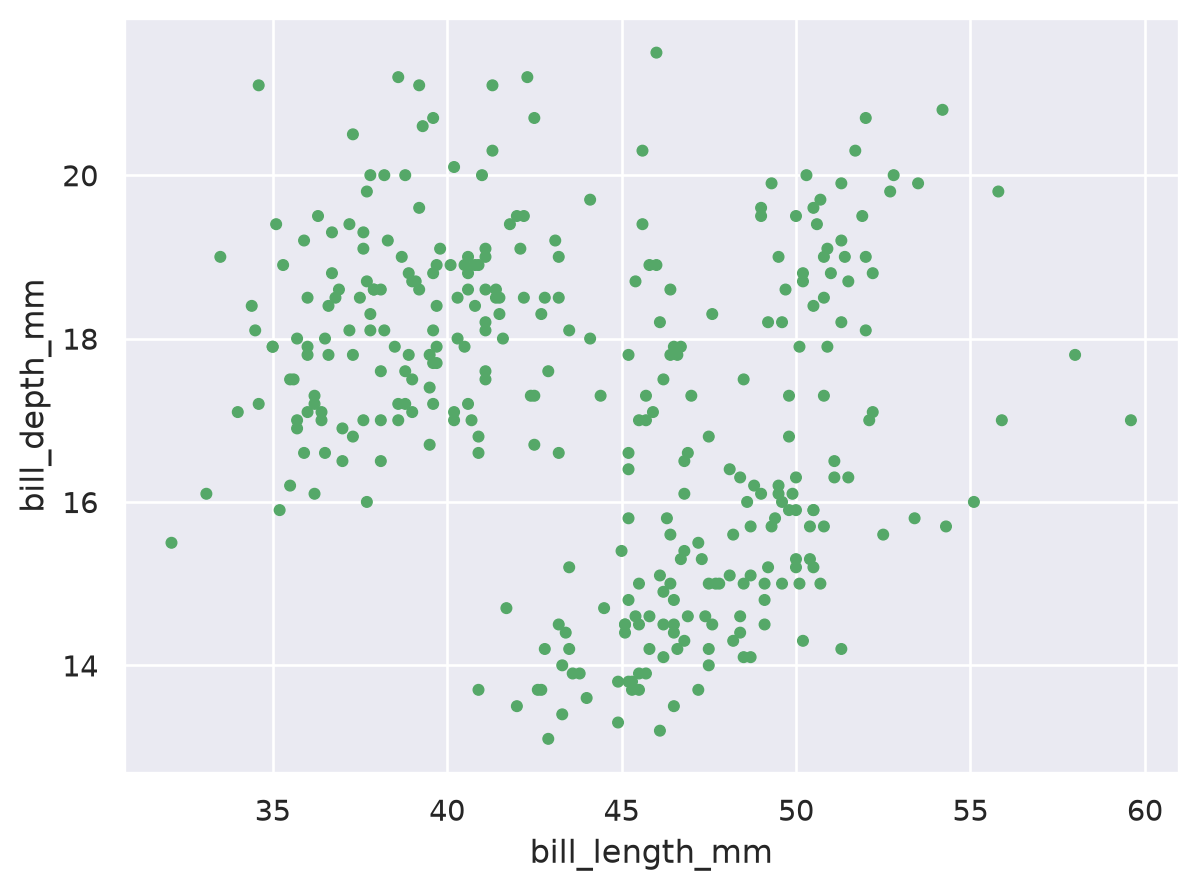

In [4]:
(
    so.Plot(penguins, x="bill_length_mm", y="bill_depth_mm")
    .add(so.Dot(color="g", pointsize=4))   # set in the Mark -> fixed value for all dots
)

### Mapping properties

Or *map* data values to properties:

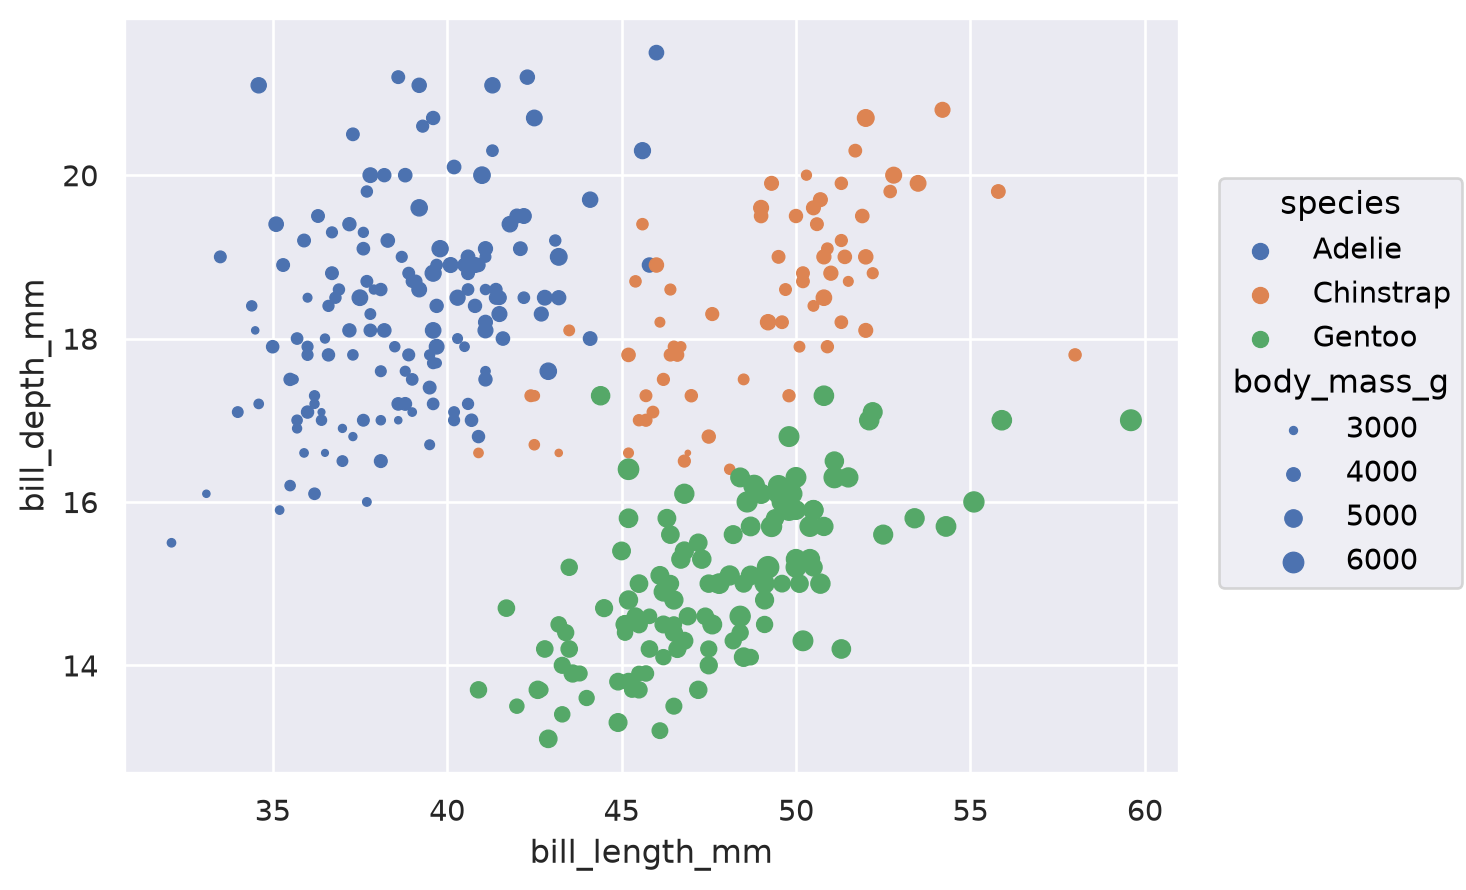

In [5]:
(
    so.Plot(
        penguins, x="bill_length_mm", y="bill_depth_mm",
        color="species", pointsize="body_mass_g",   # set in Plot -> mapped from the data
    )
    .add(so.Dot())
)

Same parameter name whether you **set** or **map** it (no `hue` vs `color`). What matters is **where** it's given: in the Mark = set directly; in `Plot` = mapped from data.
Many more properties can be mapped than in the function API:

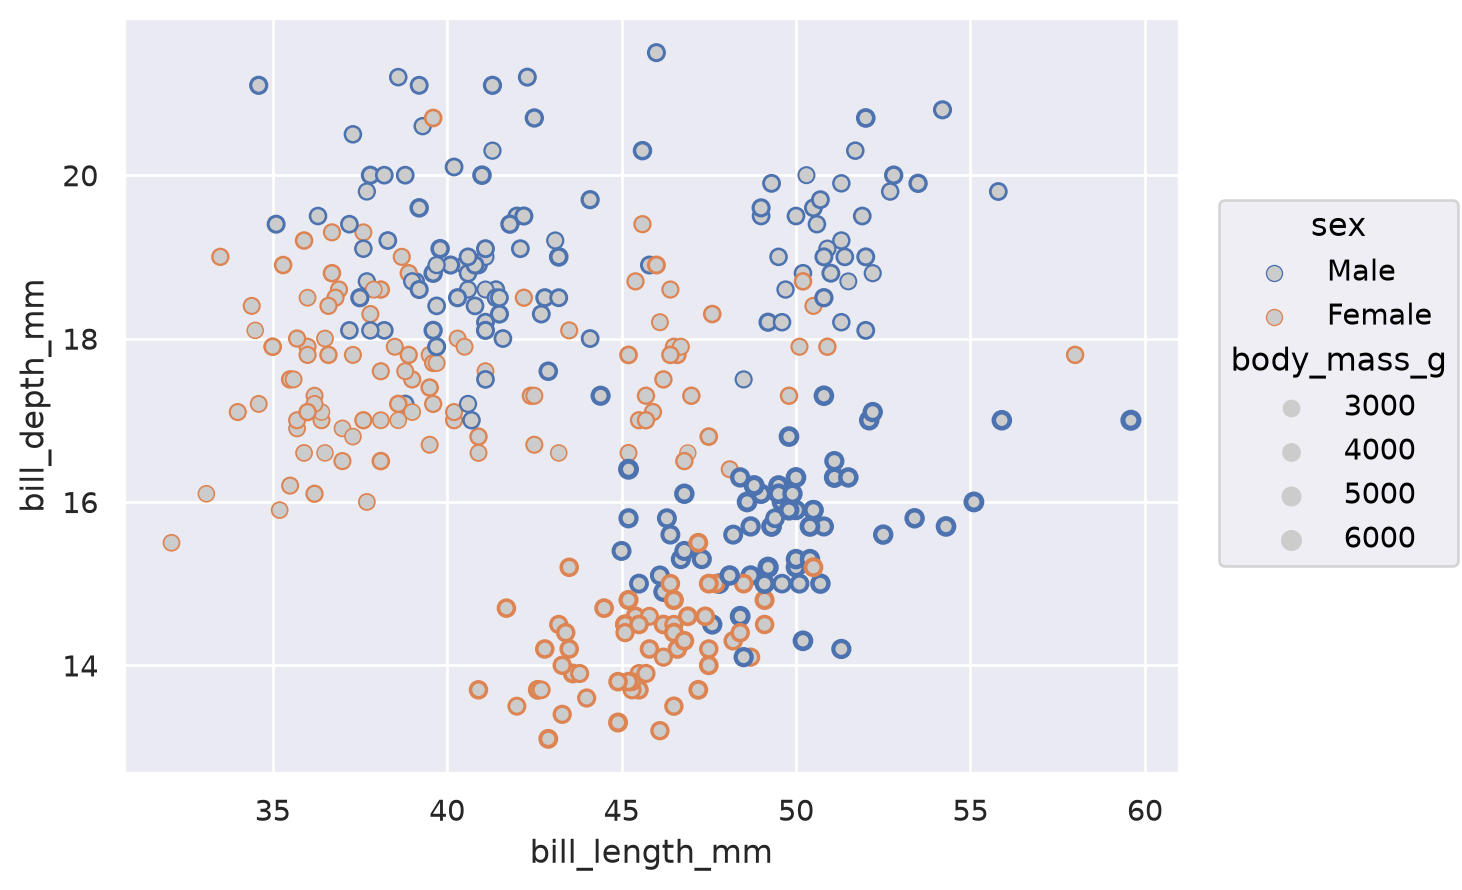

In [6]:
(
    so.Plot(
        penguins, x="bill_length_mm", y="bill_depth_mm",
        edgecolor="sex", edgewidth="body_mass_g",
    )
    .add(so.Dot(color=".8"))
)

### Defining groups

For marks that connect observations (like `Line`), a mapped variable also sets **how many** elements are drawn:

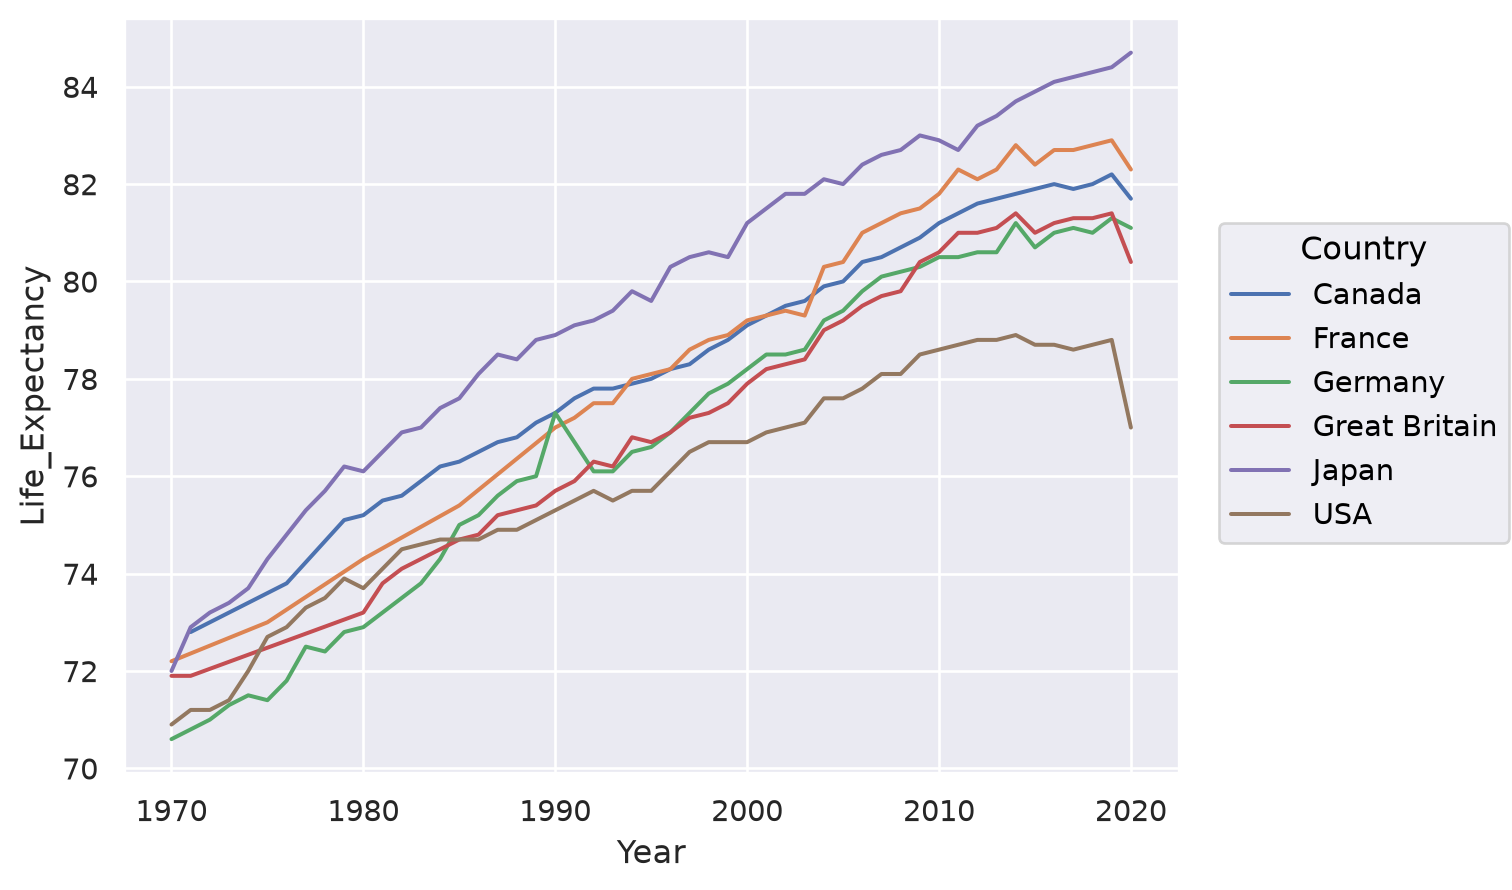

In [7]:
(
    so.Plot(healthexp, x="Year", y="Life_Expectancy", color="Country")
    .add(so.Line())   # one line per country
)

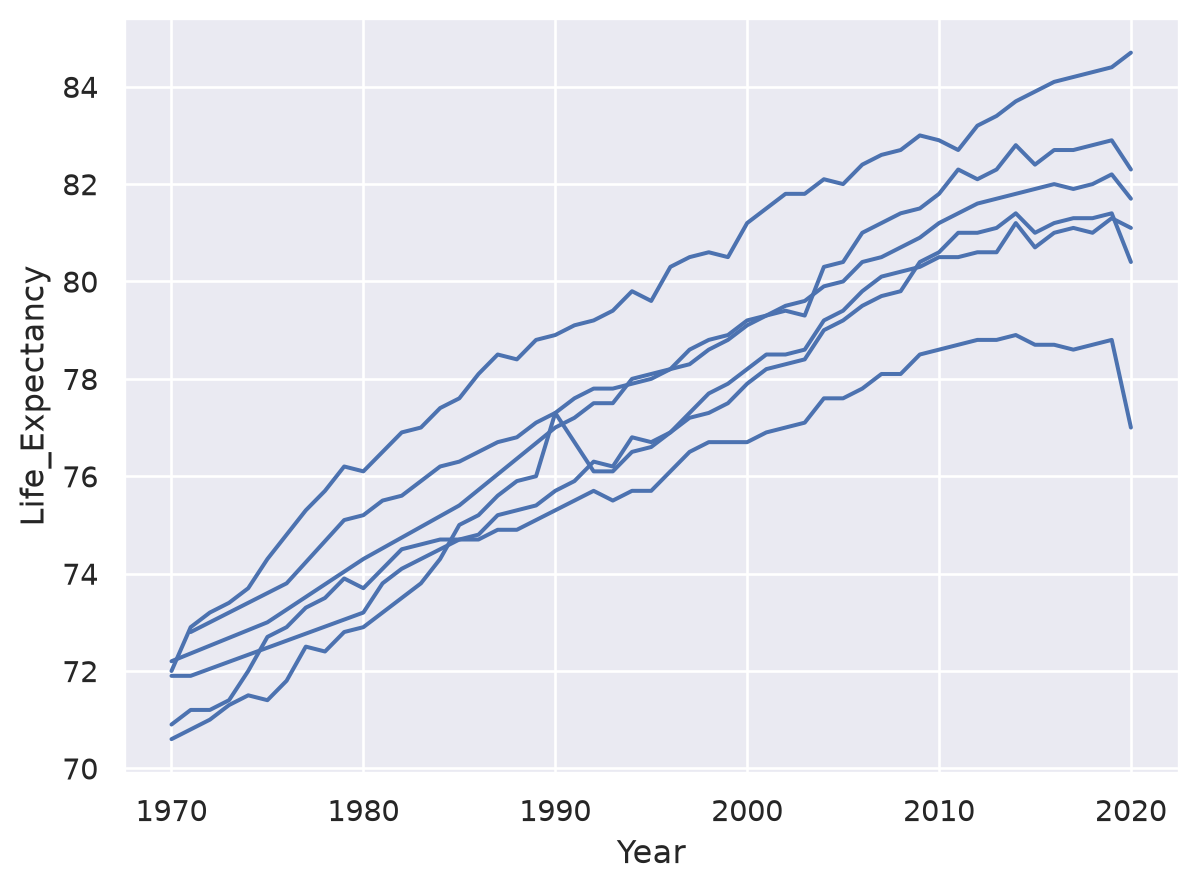

In [8]:
# Group without changing the look: group=
(
    so.Plot(healthexp, x="Year", y="Life_Expectancy", group="Country")
    .add(so.Line())
)

## Transforming data before plotting

### Statistical transformation

Done by **Stat** objects, e.g. `Agg` (aggregate, mean by default):

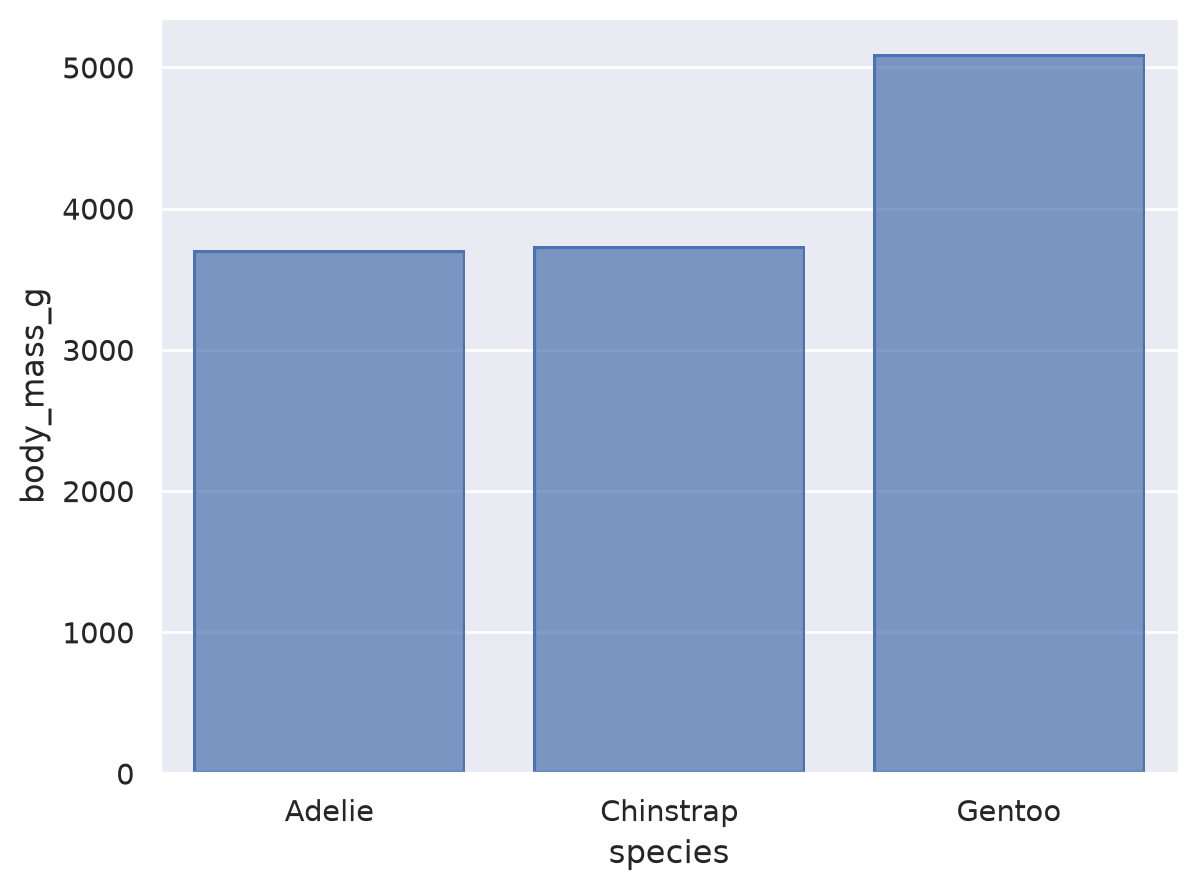

In [9]:
(
    so.Plot(penguins, x="species", y="body_mass_g")
    .add(so.Bar(), so.Agg())   # Mark + Stat: bar of the mean body mass per species
)

The function API allows stats only for some plots (`barplot` yes, `scatterplot` no). Here **representation and transformation are separate**, so you can combine any Mark with any Stat:

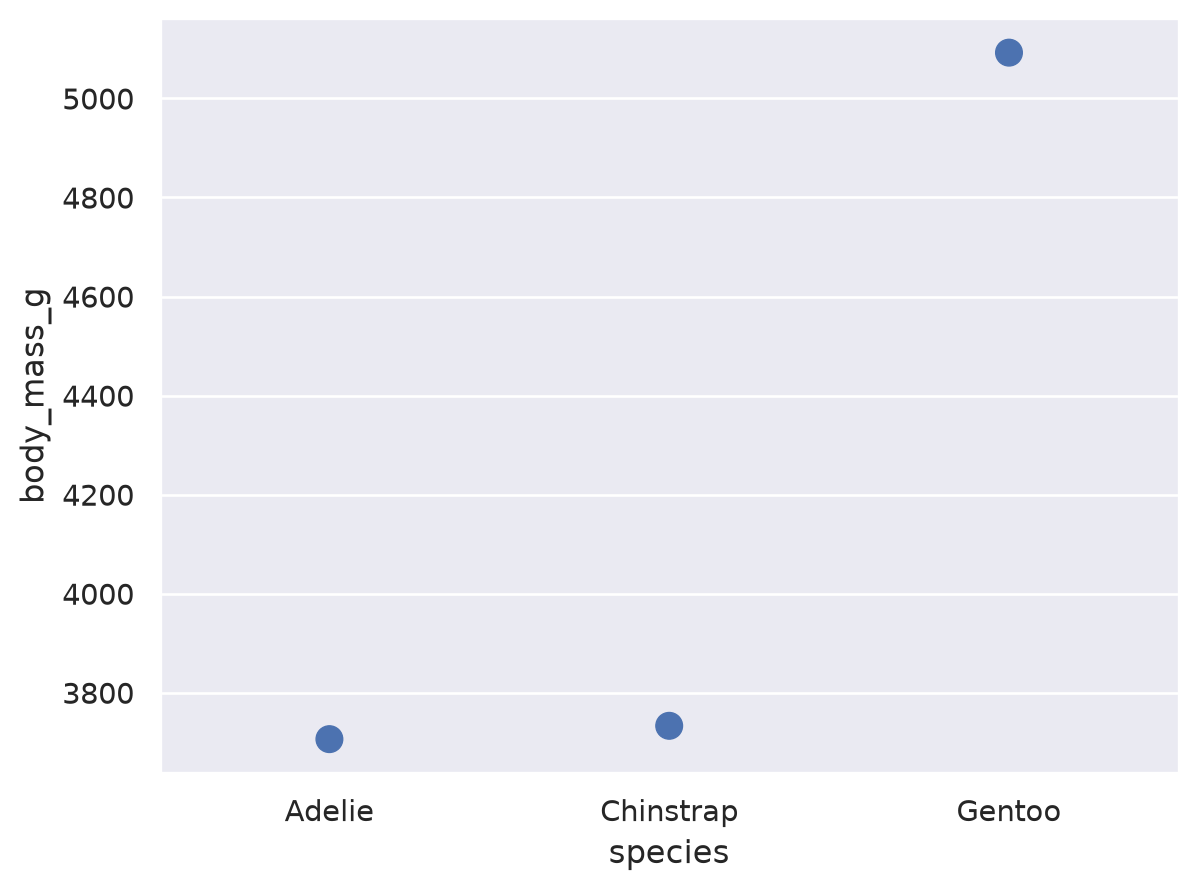

In [10]:
(
    so.Plot(penguins, x="species", y="body_mass_g")
    .add(so.Dot(pointsize=10), so.Agg())   # a dot at the mean instead of a bar
)

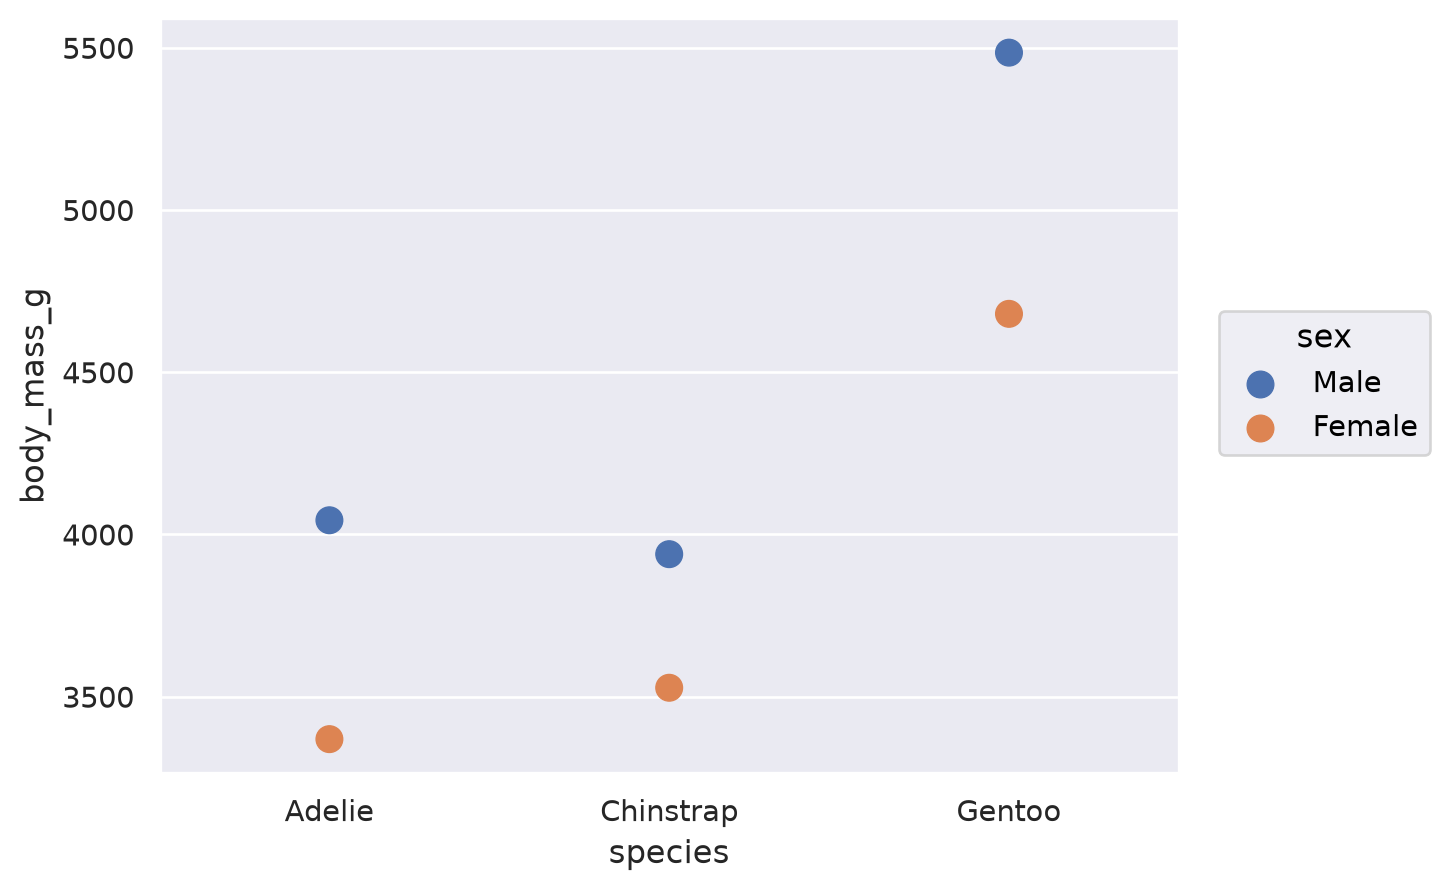

In [11]:
# Mapping a property forms groups; the Stat runs per group
(
    so.Plot(penguins, x="species", y="body_mass_g", color="sex")
    .add(so.Dot(pointsize=10), so.Agg())
)

### Resolving overplotting

Unlike `barplot` (which dodges when `hue` is set), bars for groups **overlap** by default:

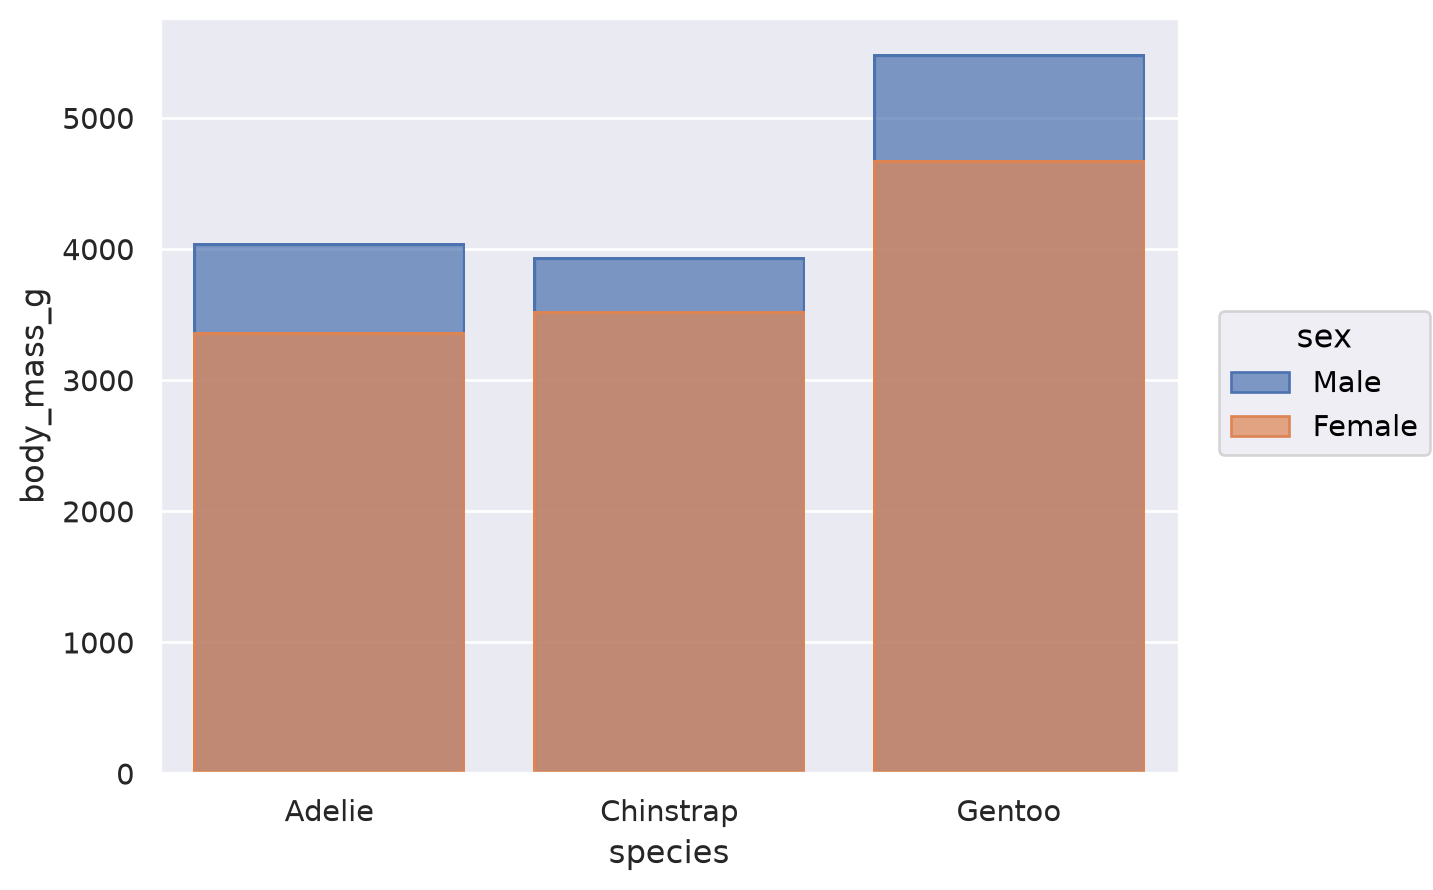

In [12]:
(
    so.Plot(penguins, x="species", y="body_mass_g", color="sex")
    .add(so.Bar(), so.Agg())
)

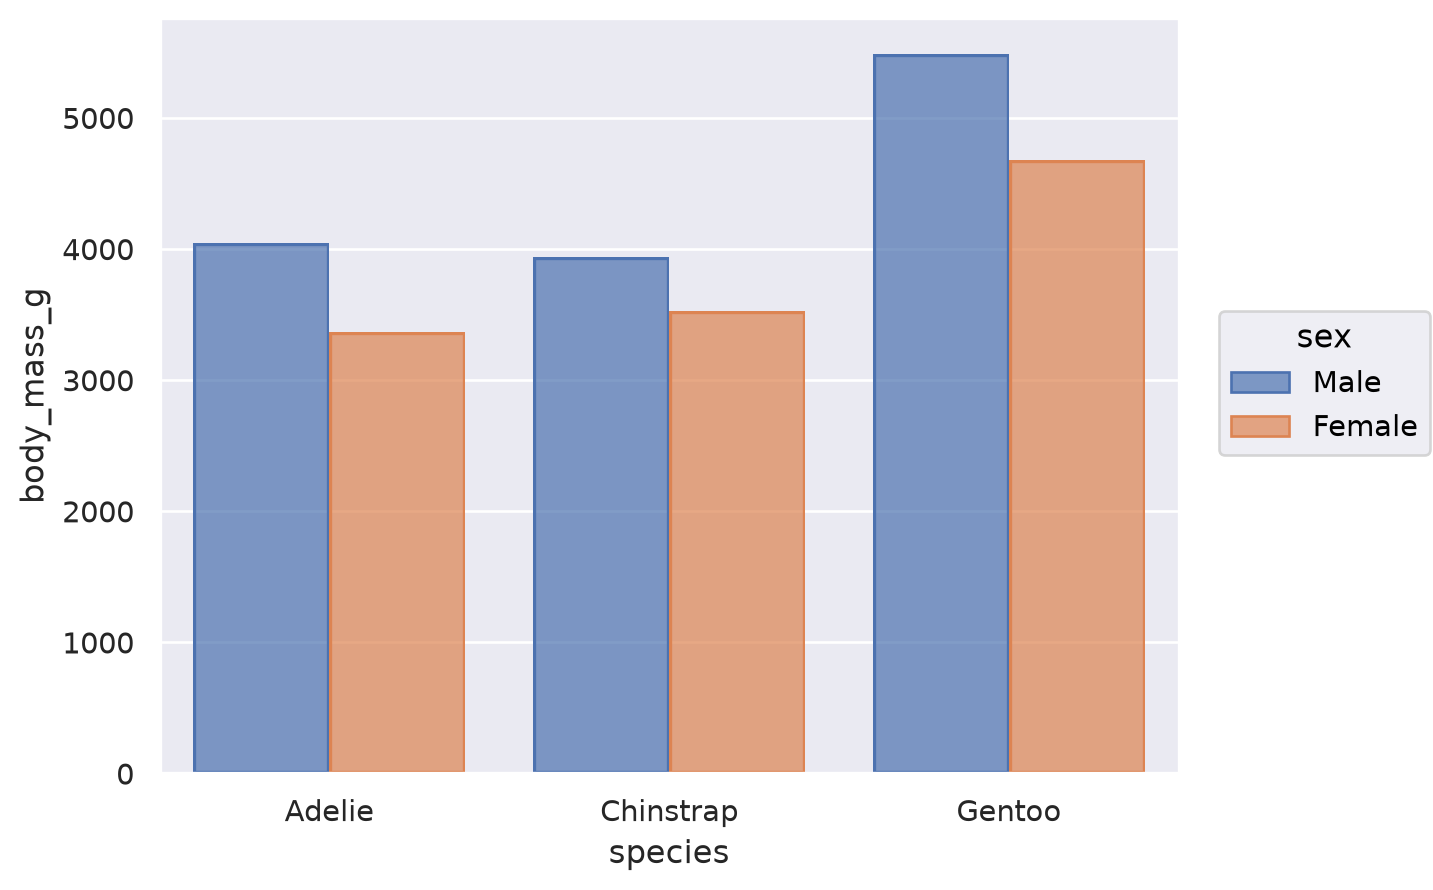

In [13]:
# Add a Dodge transformation to put the bars side by side
(
    so.Plot(penguins, x="species", y="body_mass_g", color="sex")
    .add(so.Bar(), so.Agg(), so.Dodge())
)

`Dodge` is a **Move**: like a Stat, but it only shifts `x`/`y` positions. Moves work with any mark, no Stat needed:

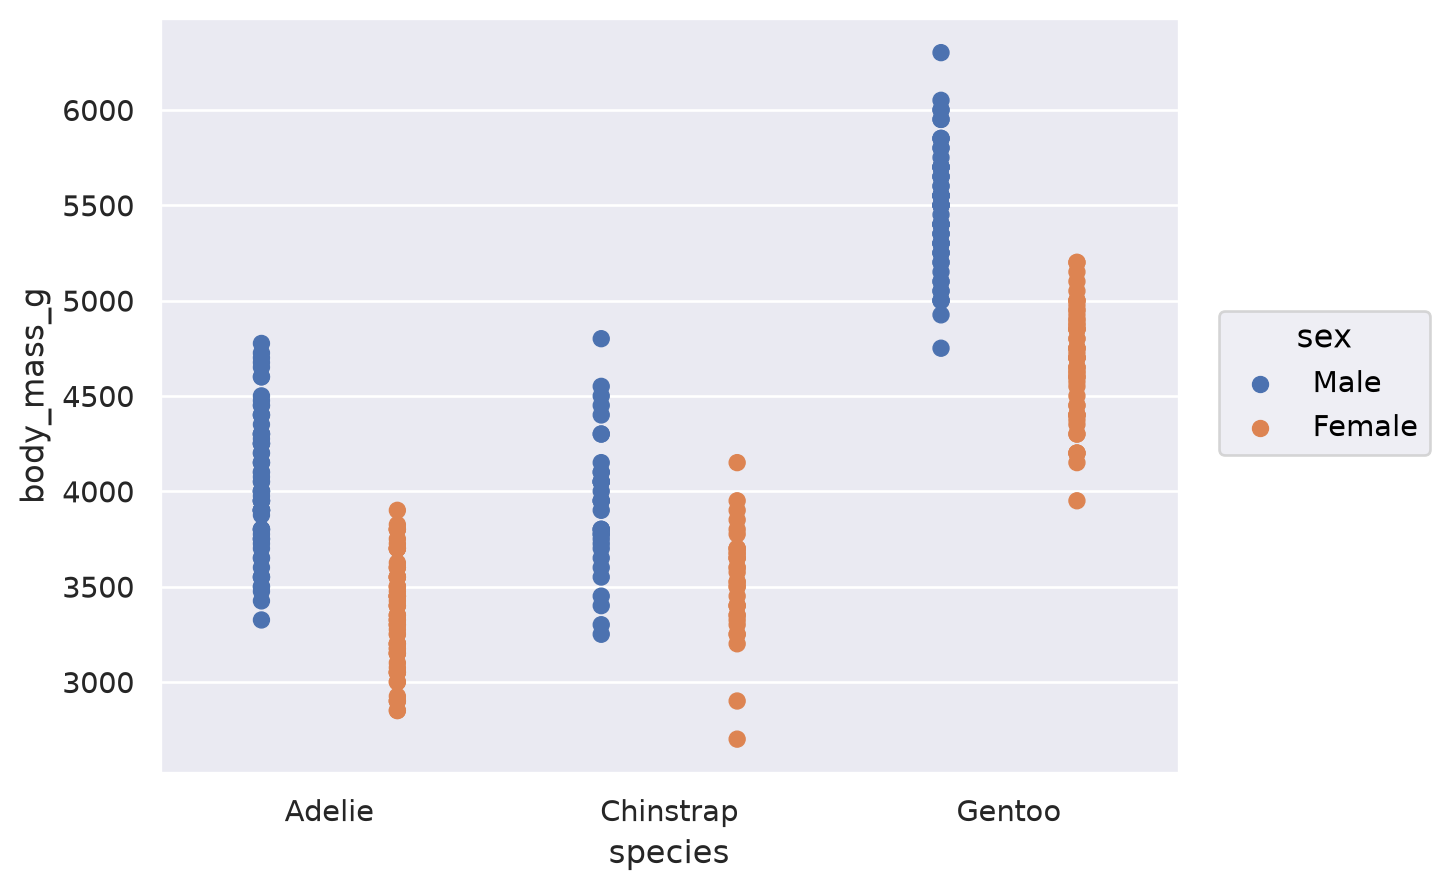

In [14]:
(
    so.Plot(penguins, x="species", y="body_mass_g", color="sex")
    .add(so.Dot(), so.Dodge())
)

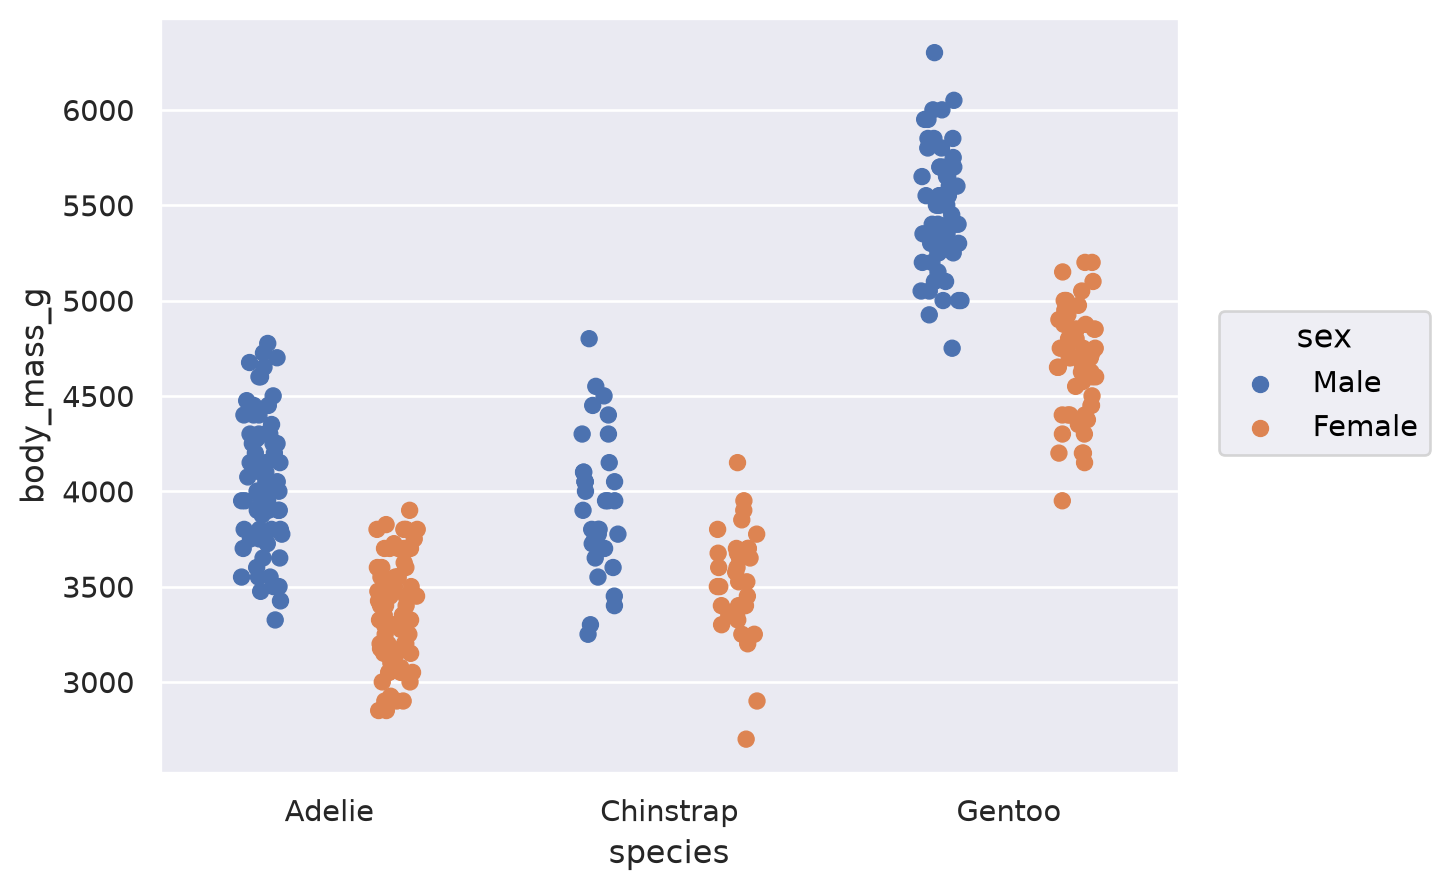

In [15]:
# Several Moves in sequence: dodge, then jitter
(
    so.Plot(penguins, x="species", y="body_mass_g", color="sex")
    .add(so.Dot(), so.Dodge(), so.Jitter(.3))
)

### Creating variables through transformation

`Agg` needs both `x` and `y`. Some Stats **create** a variable, e.g. `Hist` counts observations and creates `y`:

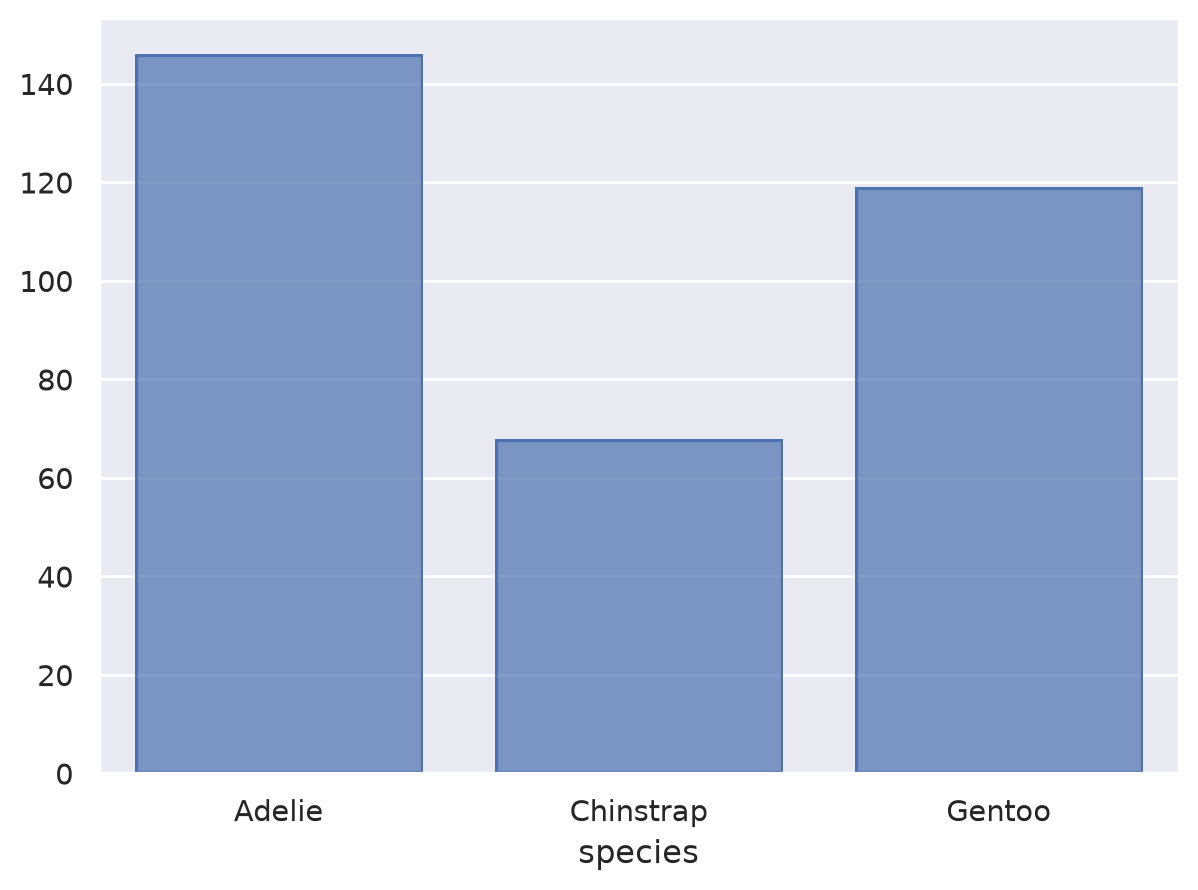

In [16]:
(
    so.Plot(penguins, x="species")
    .add(so.Bar(), so.Hist())   # y = count per species
)

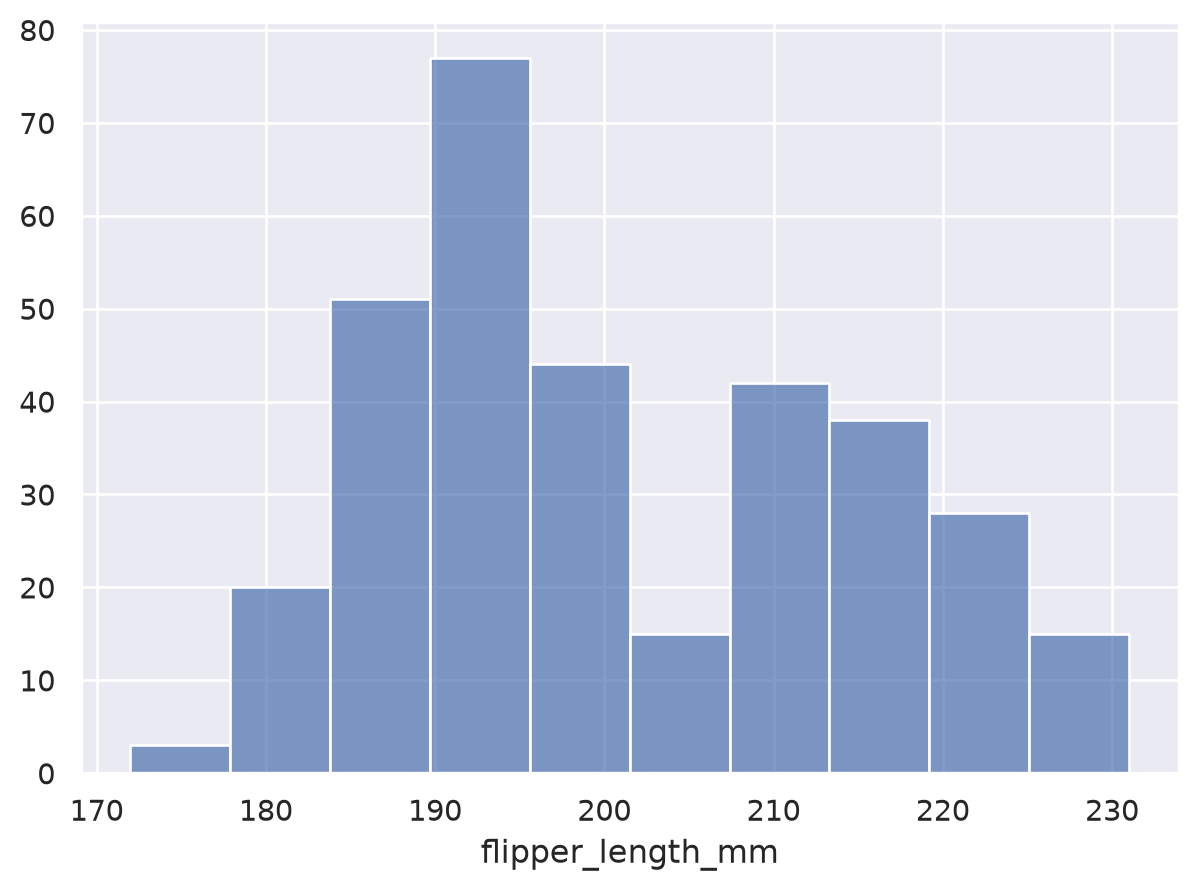

In [17]:
# With numeric data, Hist also creates new x values by binning
(
    so.Plot(penguins, x="flipper_length_mm")
    .add(so.Bars(), so.Hist())   # Bars (plural) is better for continuous histograms
)

`Bar` vs `Bars`: plural marks have different defaults and are optimised for **many** elements (continuous axes). This singular/plural pattern appears elsewhere (`Dot`/`Dots`).

Some transforms add **intervals**, e.g. error bars after aggregation:

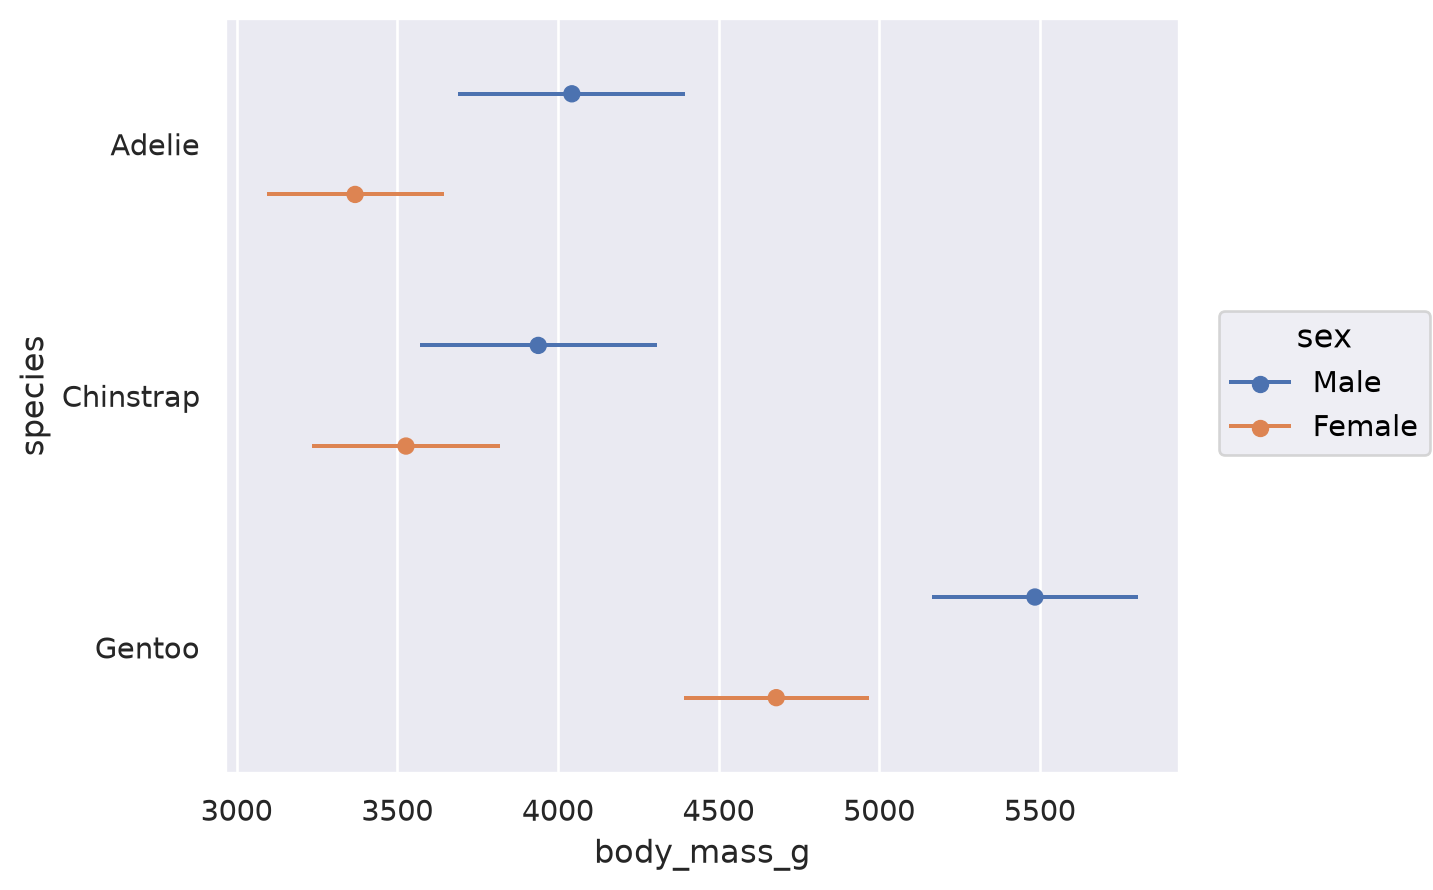

In [18]:
(
    so.Plot(penguins, x="body_mass_g", y="species", color="sex")
    .add(so.Range(), so.Est(errorbar="sd"), so.Dodge())   # layer 1: mean ± 1 SD as a range
    .add(so.Dot(), so.Agg(), so.Dodge())                  # layer 2: the mean as a dot
)

### Orienting marks and transforms

Aggregating, dodging and bars treat `x` and `y` differently (an *orientation*). `Plot` guesses it from the data types; swap the variables and you get a horizontal plot:

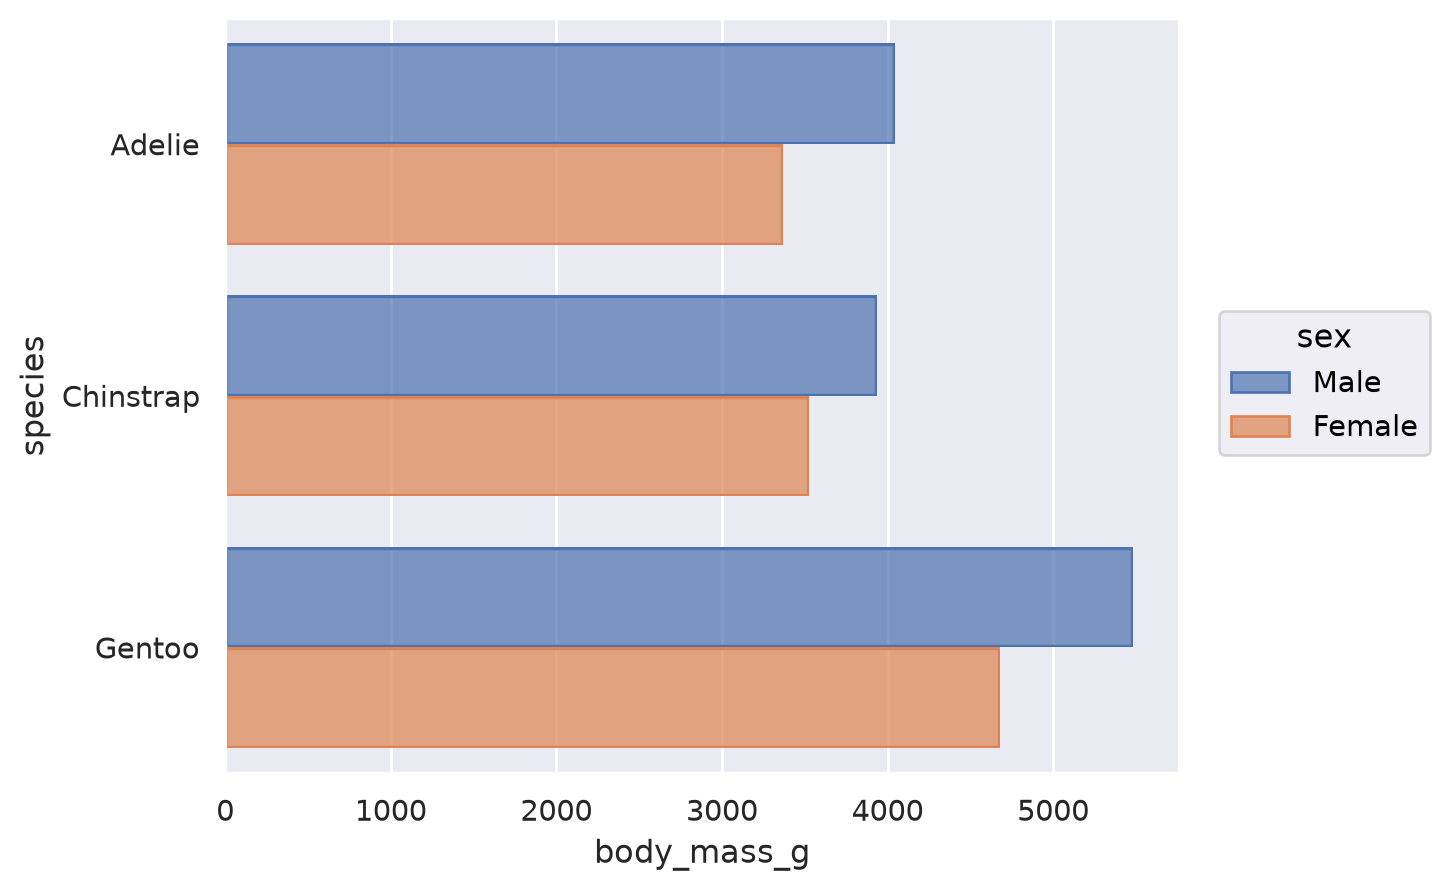

In [19]:
(
    so.Plot(penguins, x="body_mass_g", y="species", color="sex")
    .add(so.Bar(), so.Agg(), so.Dodge())
)

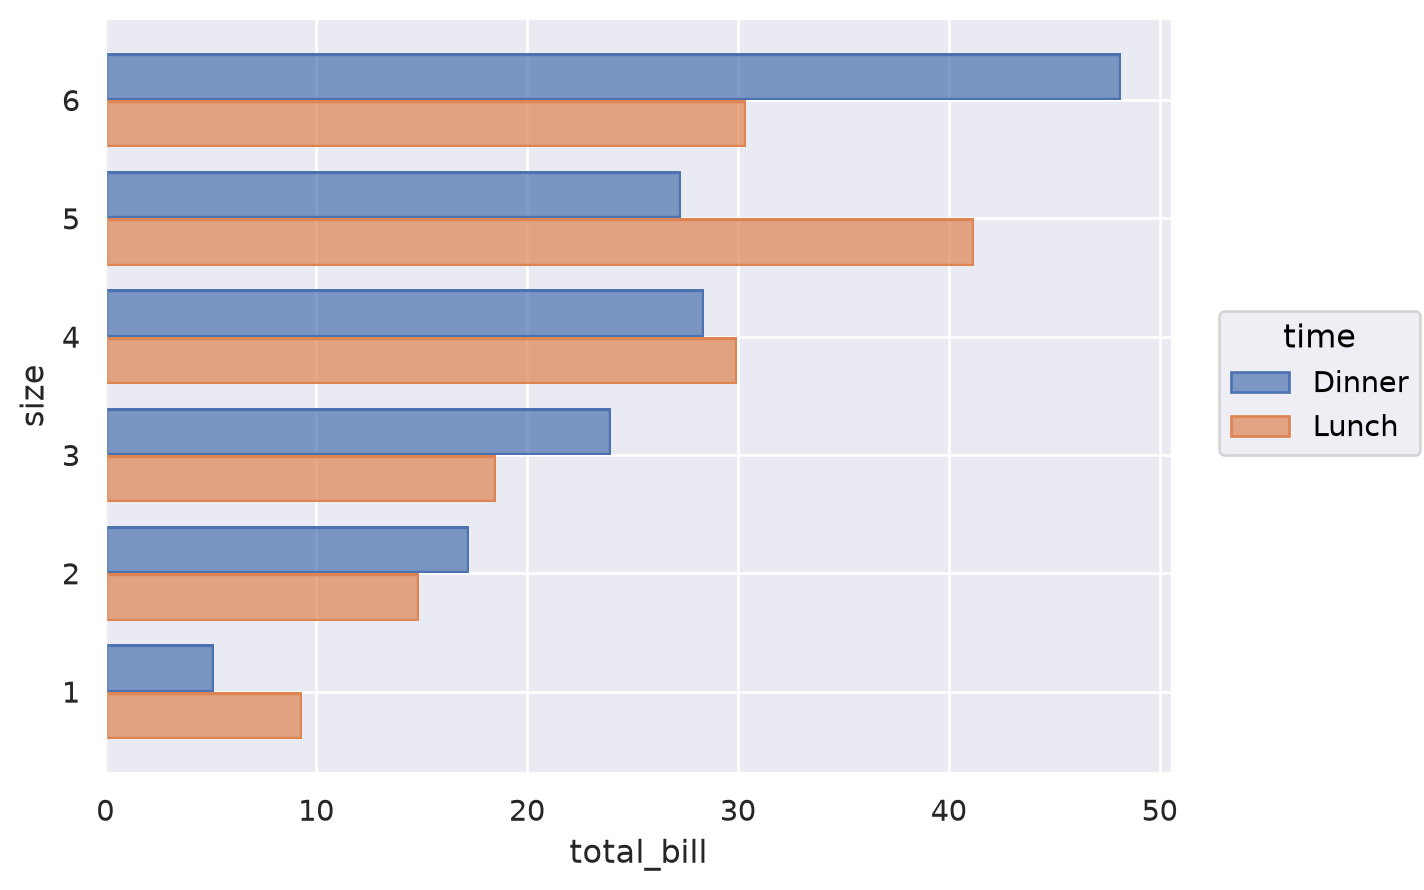

In [20]:
# Both numeric -> ambiguous: say it explicitly with orient=
(
    so.Plot(tips, x="total_bill", y="size", color="time")
    .add(so.Bar(), so.Agg(), so.Dodge(), orient="y")
)

## Building and displaying the plot

### Adding multiple layers

Each `.add()` call is a **layer**. Scatter + regression fit:

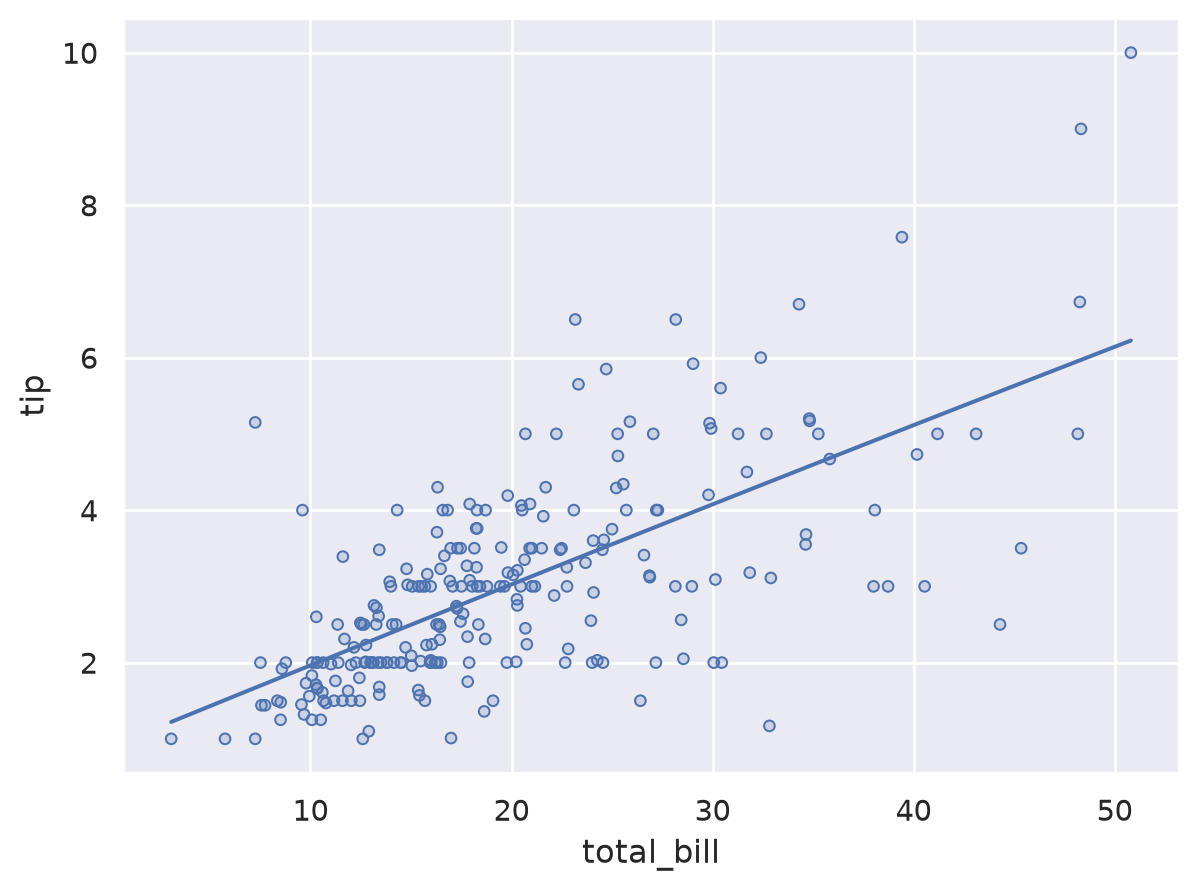

In [21]:
(
    so.Plot(tips, x="total_bill", y="tip")
    .add(so.Dots())                  # layer 1: points
    .add(so.Line(), so.PolyFit())    # layer 2: a fitted line (Line mark + PolyFit stat)
)

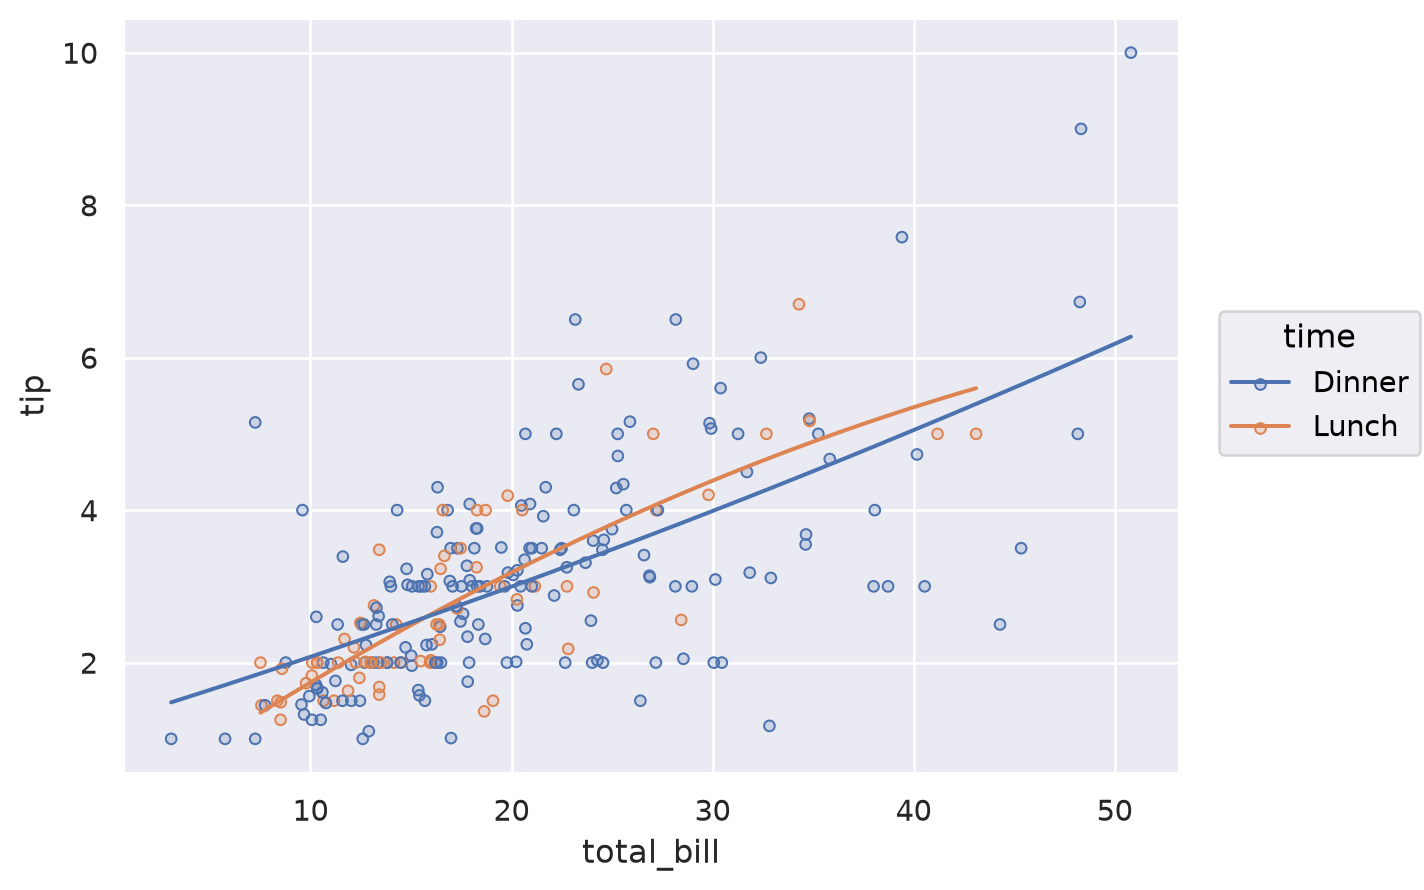

In [22]:
# Mappings defined in Plot() apply to ALL layers
(
    so.Plot(tips, x="total_bill", y="tip", color="time")
    .add(so.Dots())
    .add(so.Line(), so.PolyFit())   # one fit per time
)

### Layer-specific mappings

Map a variable in **one** layer only by giving it in that `.add()`:

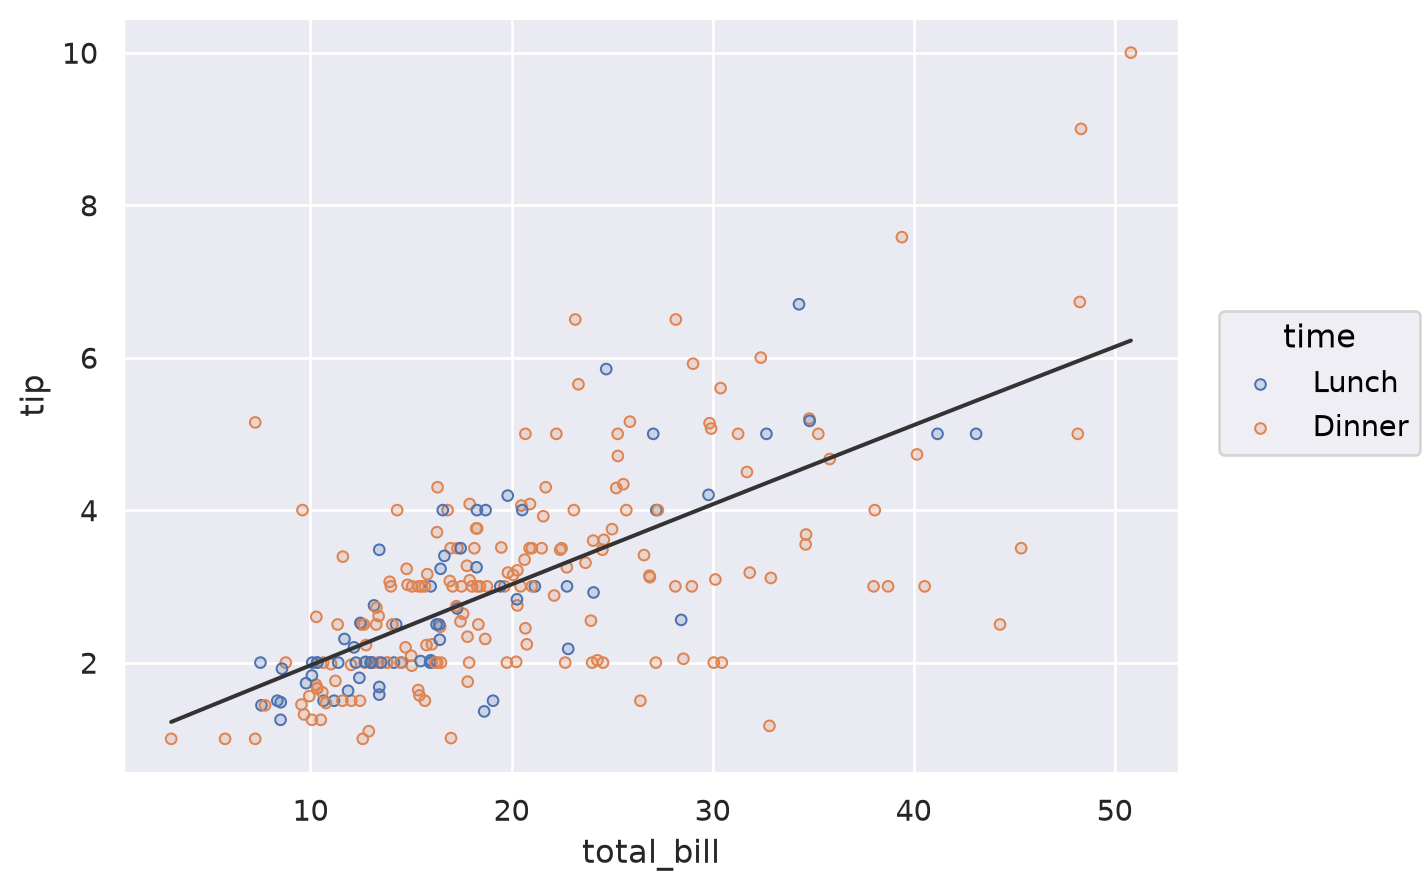

In [23]:
(
    so.Plot(tips, x="total_bill", y="tip")
    .add(so.Dots(), color="time")              # colour only the points
    .add(so.Line(color=".2"), so.PolyFit())    # one dark-grey fit for all data
)

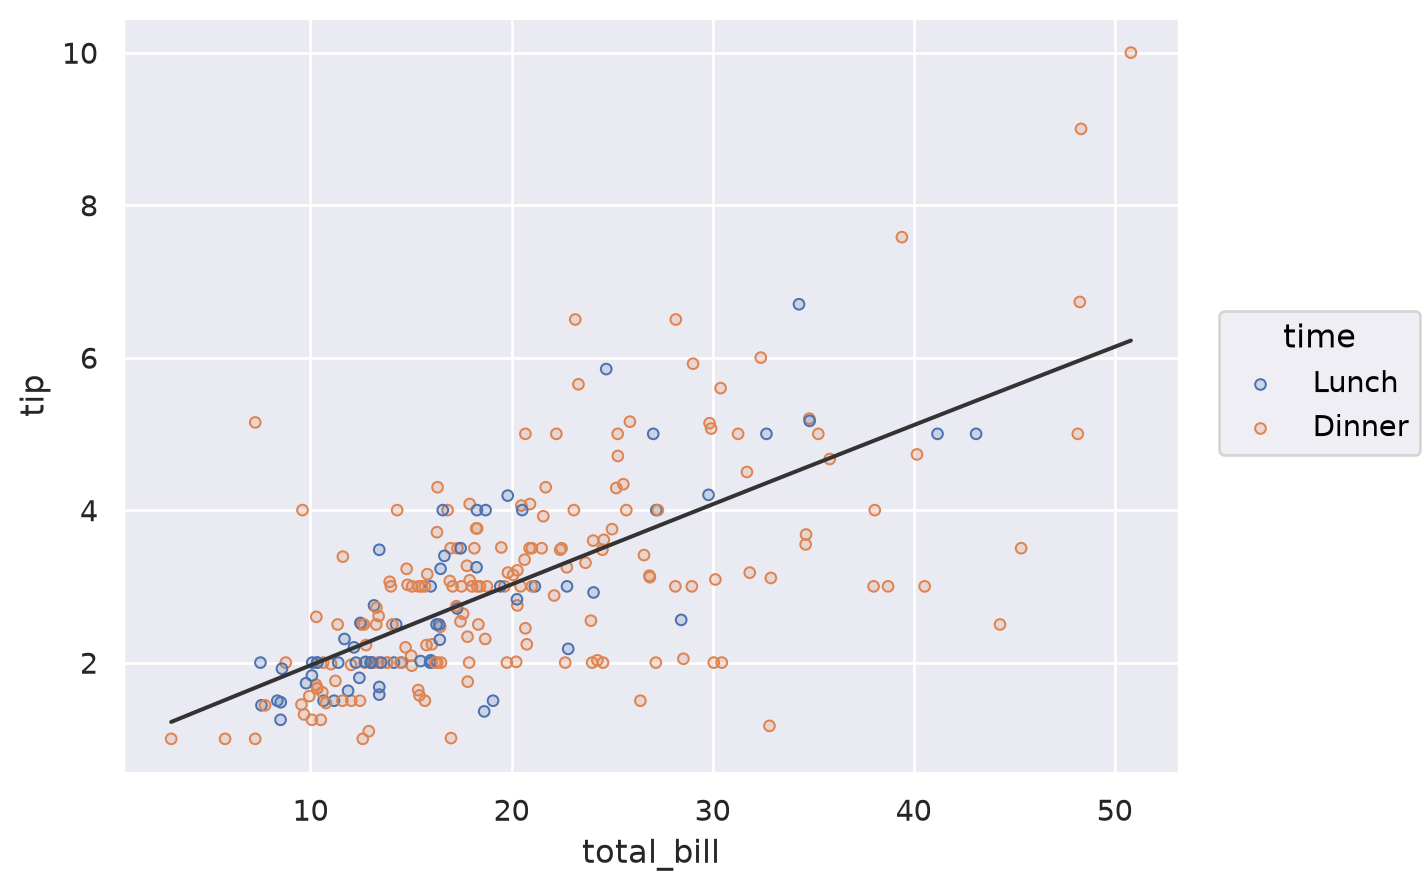

In [24]:
# Or map it for the whole plot and REMOVE it from one layer with None
(
    so.Plot(tips, x="total_bill", y="tip", color="time")
    .add(so.Dots())
    .add(so.Line(color=".2"), so.PolyFit(), color=None)
)

Recap, three ways to give a mark property a value:

```python
so.Plot(data, 'x', 'y', color='var1')          # mapped in ALL layers
  .add(so.Dot(pointsize=10), marker='var2')    # pointsize: set directly | marker: mapped in THIS layer
```

### Faceting and pairing subplots

Like the figure-level functions, `Plot.facet` makes subplots with subsets of the data:

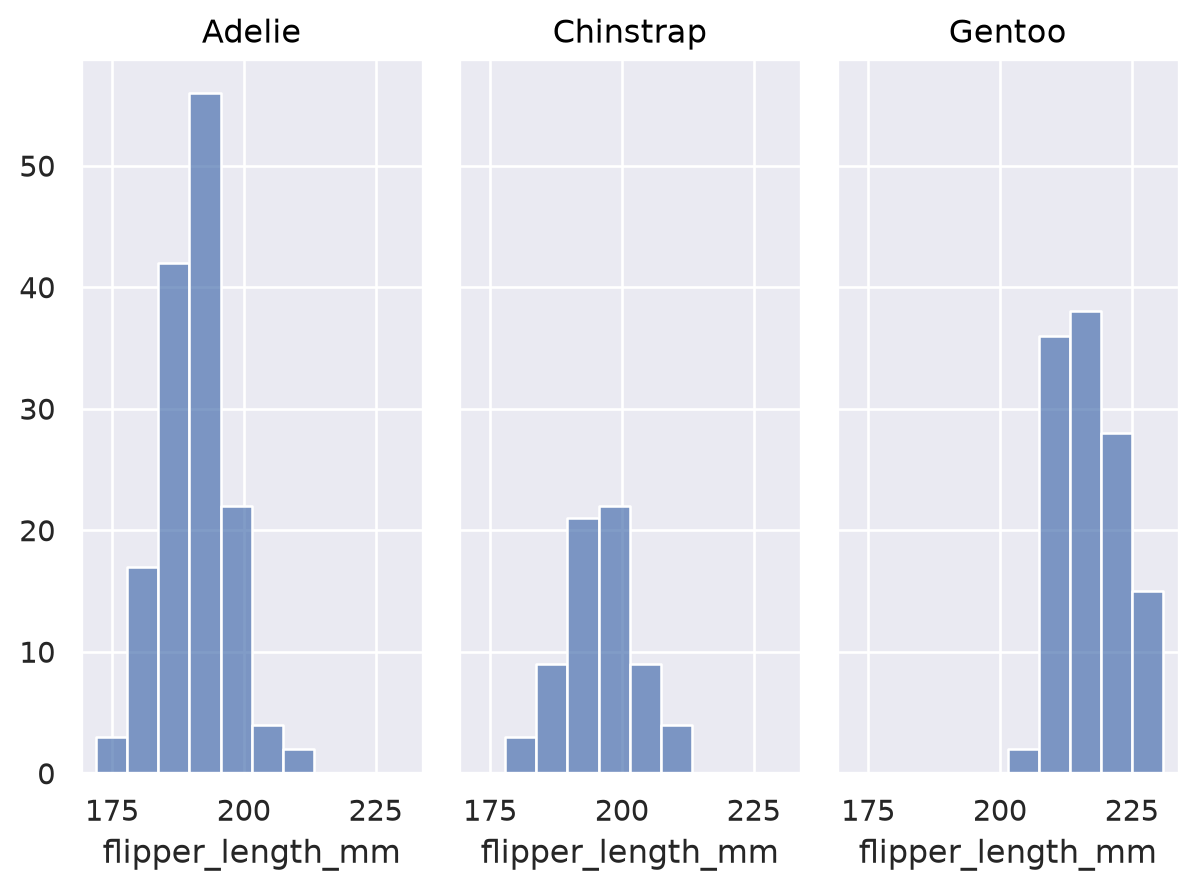

In [25]:
(
    so.Plot(penguins, x="flipper_length_mm")
    .facet("species")               # one column per species
    .add(so.Bars(), so.Hist())
)

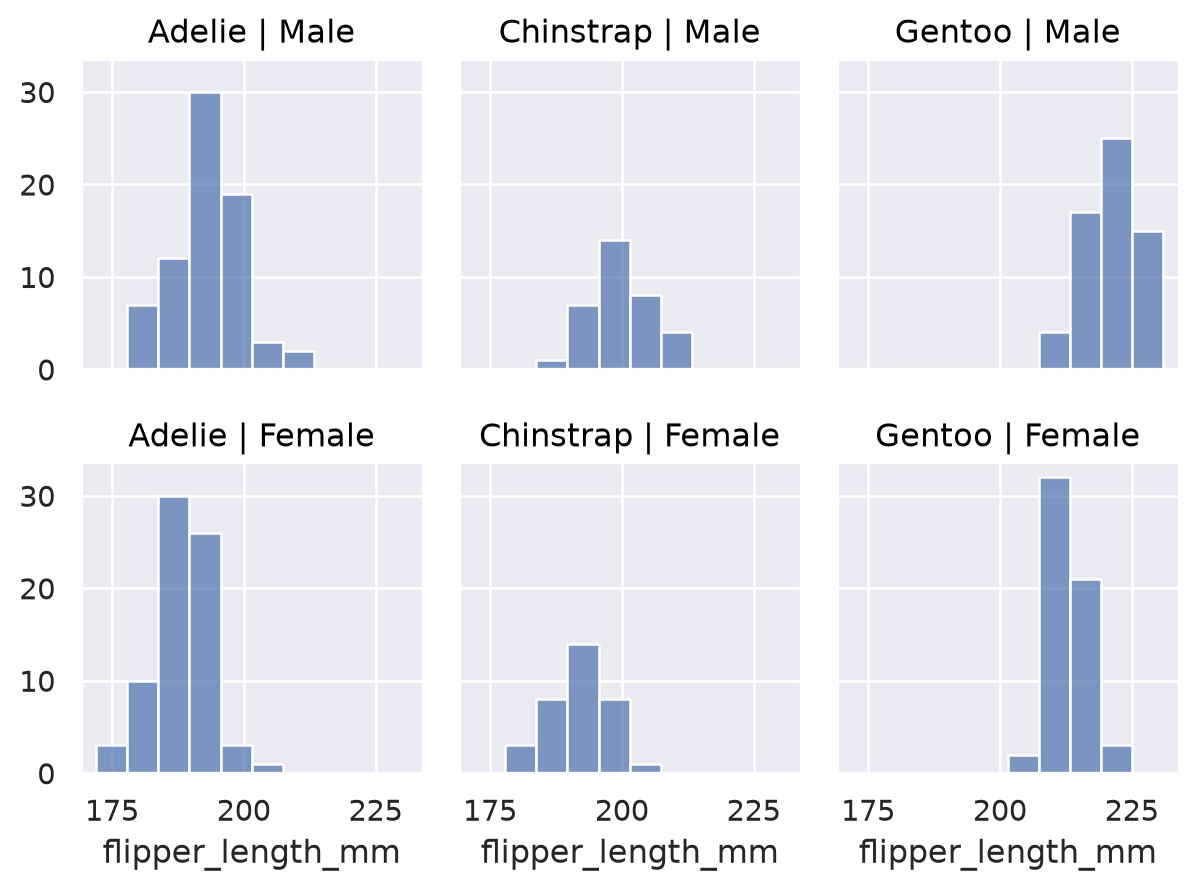

In [26]:
(
    so.Plot(penguins, x="flipper_length_mm")
    .facet(col="species", row="sex")   # columns AND rows
    .add(so.Bars(), so.Hist())
)

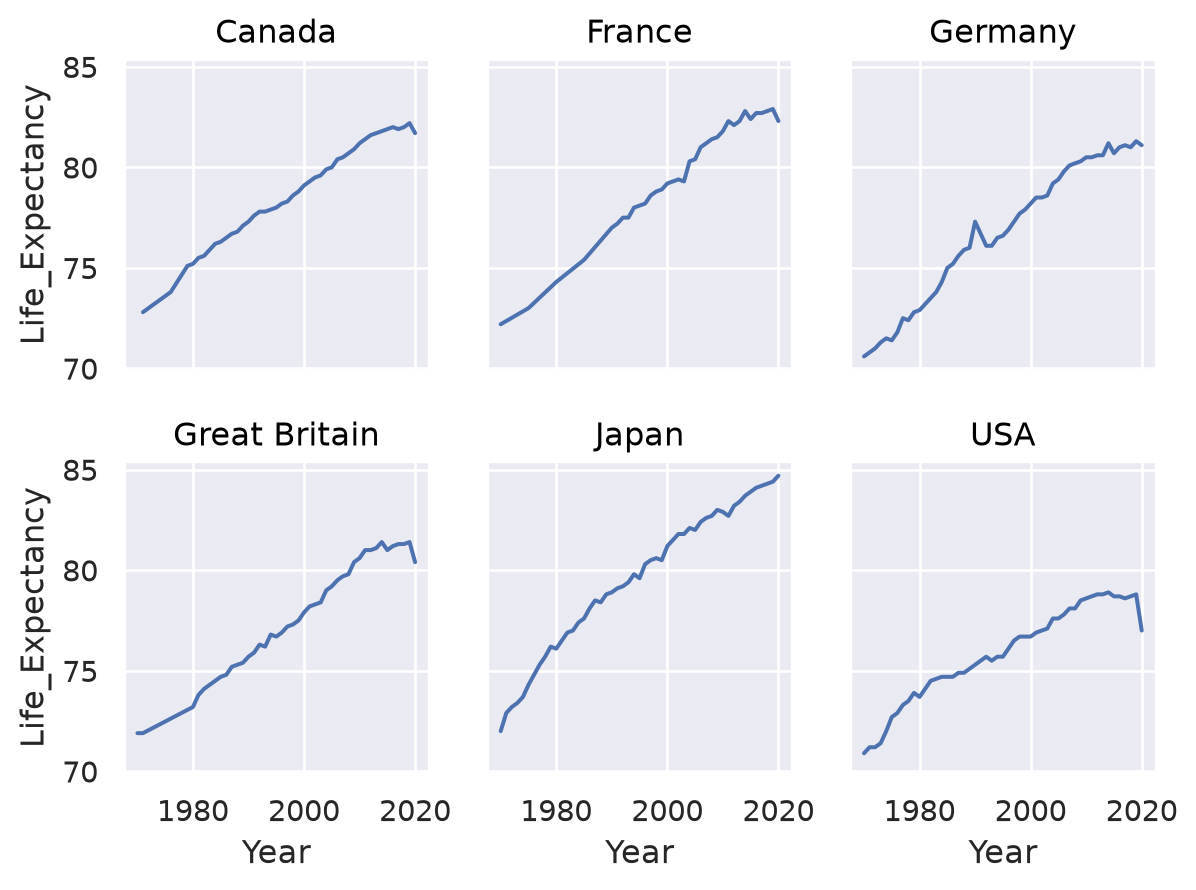

In [27]:
# Many levels? wrap across rows
(
    so.Plot(healthexp, x="Year", y="Life_Expectancy")
    .facet(col="Country", wrap=3)
    .add(so.Line())
)

All layers are faceted unless you exclude one. Here a faint layer with **every** country gives context in each panel:

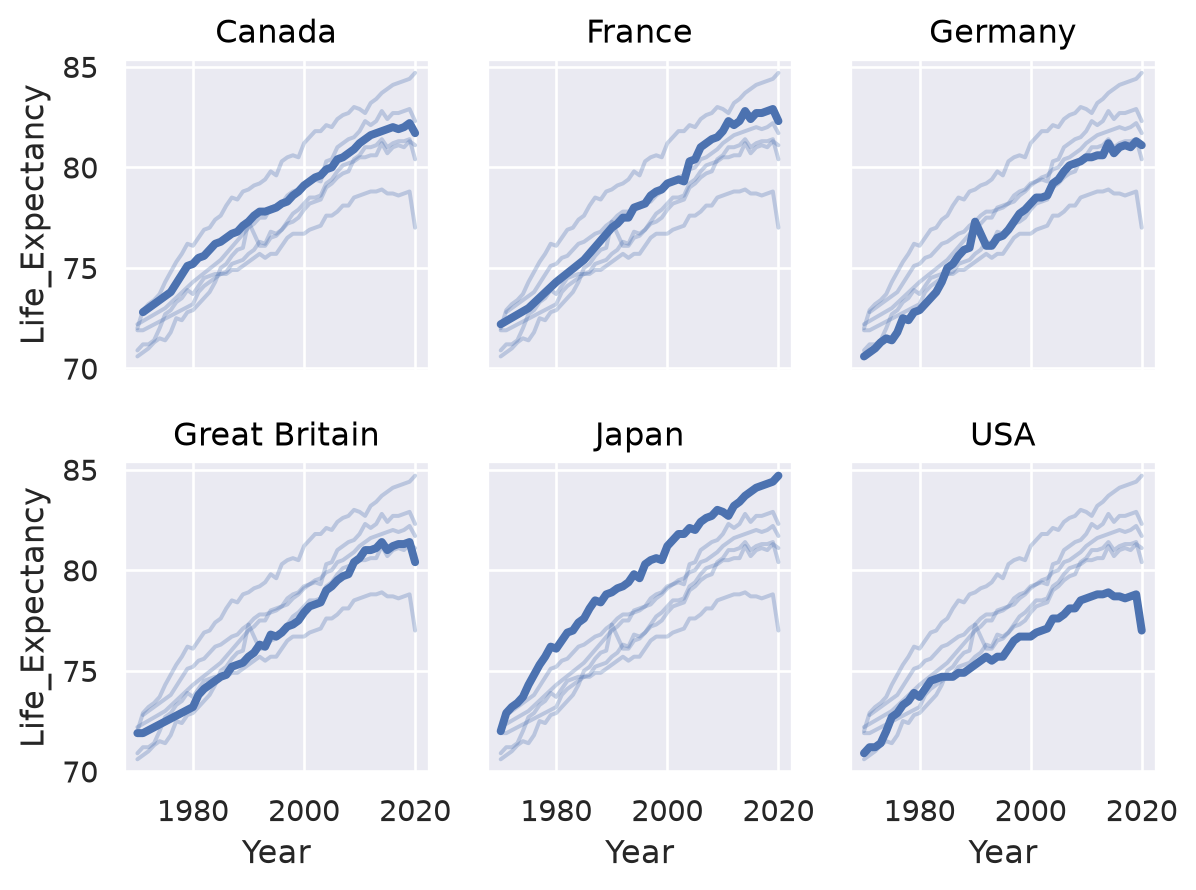

In [28]:
(
    so.Plot(healthexp, x="Year", y="Life_Expectancy")
    .facet("Country", wrap=3)
    .add(so.Line(alpha=.3), group="Country", col=None)   # col=None -> this layer is not split by facet
    .add(so.Line(linewidth=3))
)

`Plot.pair` (like `PairGrid`) draws **all** the data in each subplot, but with different x and/or y variables:

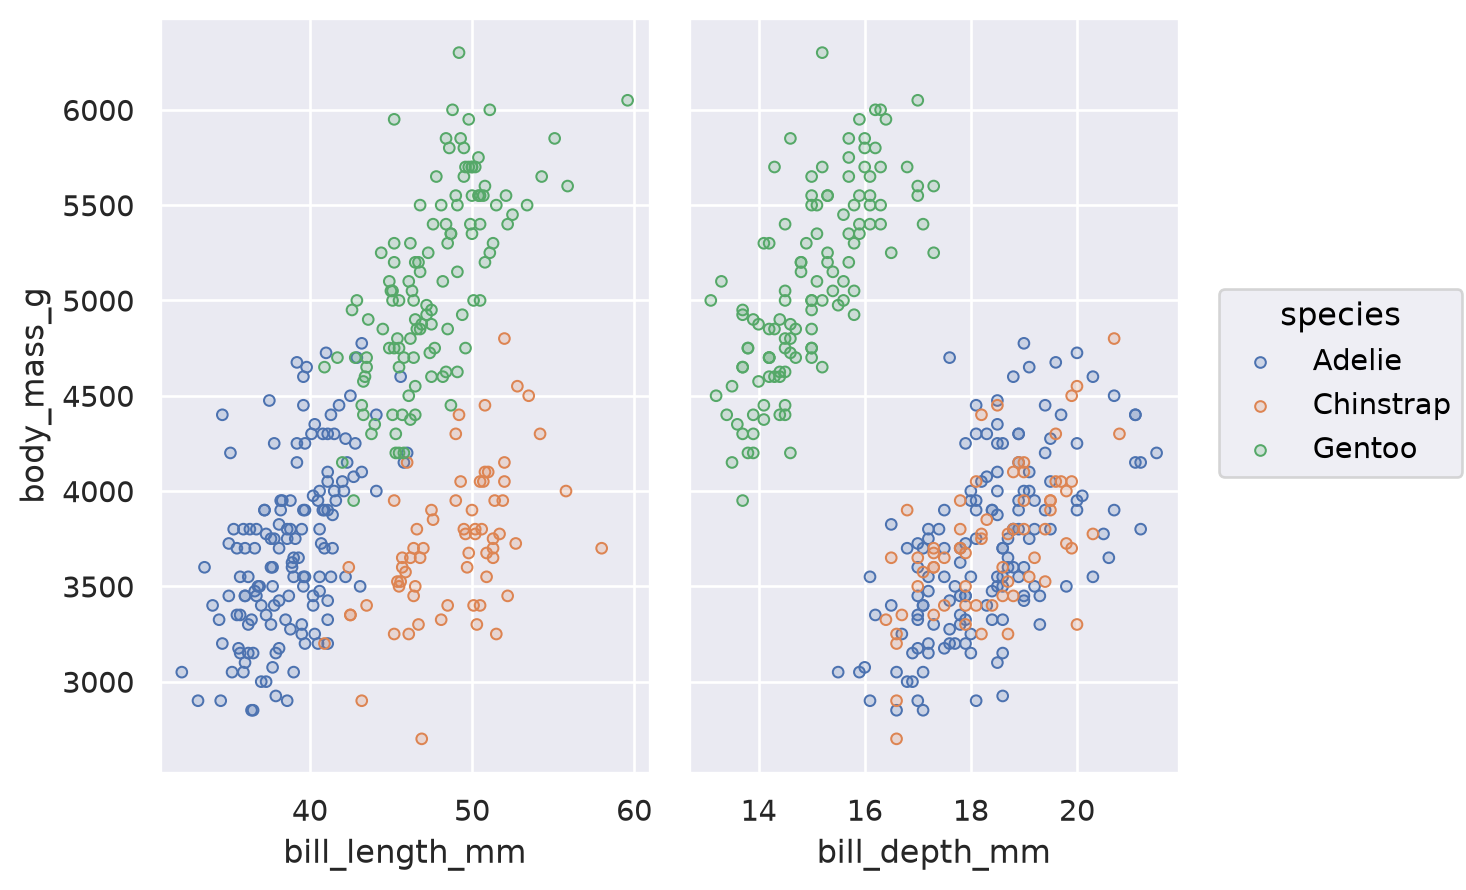

In [29]:
(
    so.Plot(penguins, y="body_mass_g", color="species")
    .pair(x=["bill_length_mm", "bill_depth_mm"])   # one subplot per x variable
    .add(so.Dots())
)

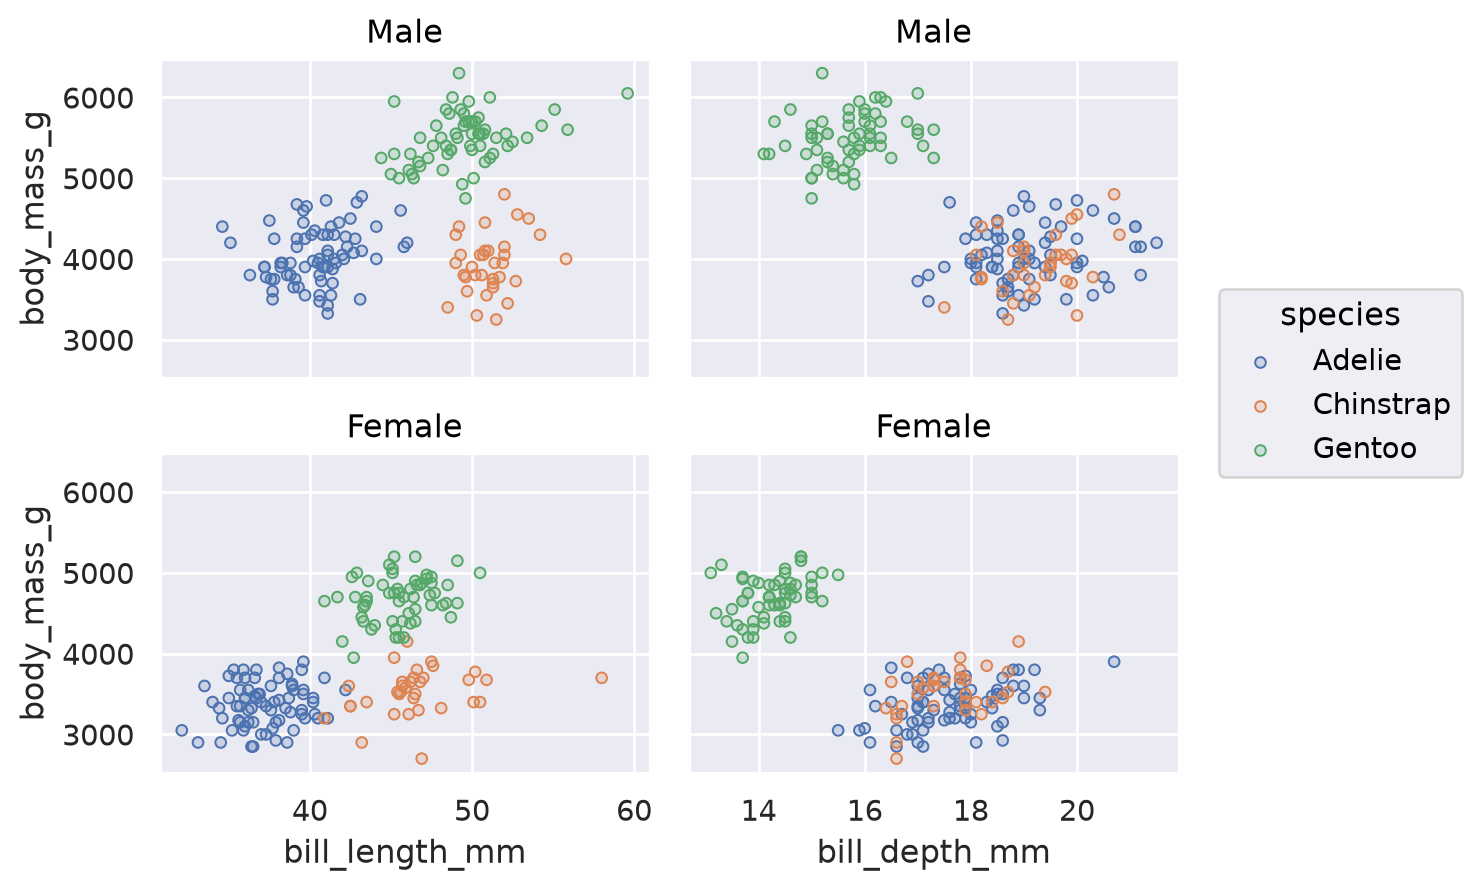

In [30]:
# Facet and pair together, as long as they add subplots on opposite dimensions
(
    so.Plot(penguins, y="body_mass_g", color="species")
    .pair(x=["bill_length_mm", "bill_depth_mm"])
    .facet(row="sex")
    .add(so.Dots())
)

### Integrating with matplotlib

For layouts that `facet`/`pair` can't make, build the figure in matplotlib and hand it over with `Plot.on(...)`: an `Axes`, a `Figure` or a `SubFigure`.

In [31]:
f = mpl.figure.Figure(figsize=(8, 4))
sf1, sf2 = f.subfigures(1, 2)          # matplotlib makes two subfigures
(
    so.Plot(penguins, x="body_mass_g", y="flipper_length_mm")
    .add(so.Dots())
    .on(sf1)                           # draw into the left subfigure
    .plot()
)
(
    so.Plot(penguins, x="body_mass_g")
    .facet(row="sex")
    .add(so.Bars(), so.Hist())
    .on(sf2)                           # draw into the right subfigure
    .plot()
)
f   # display the matplotlib figure

<Figure size 800x400 with 3 Axes>

### Building and displaying the plot

`Plot` methods **return a clone** instead of changing the object in place. So you can define a base spec and make variations:

In [32]:
p = so.Plot(healthexp, "Year", "Spending_USD", color="Country")   # nothing is drawn yet

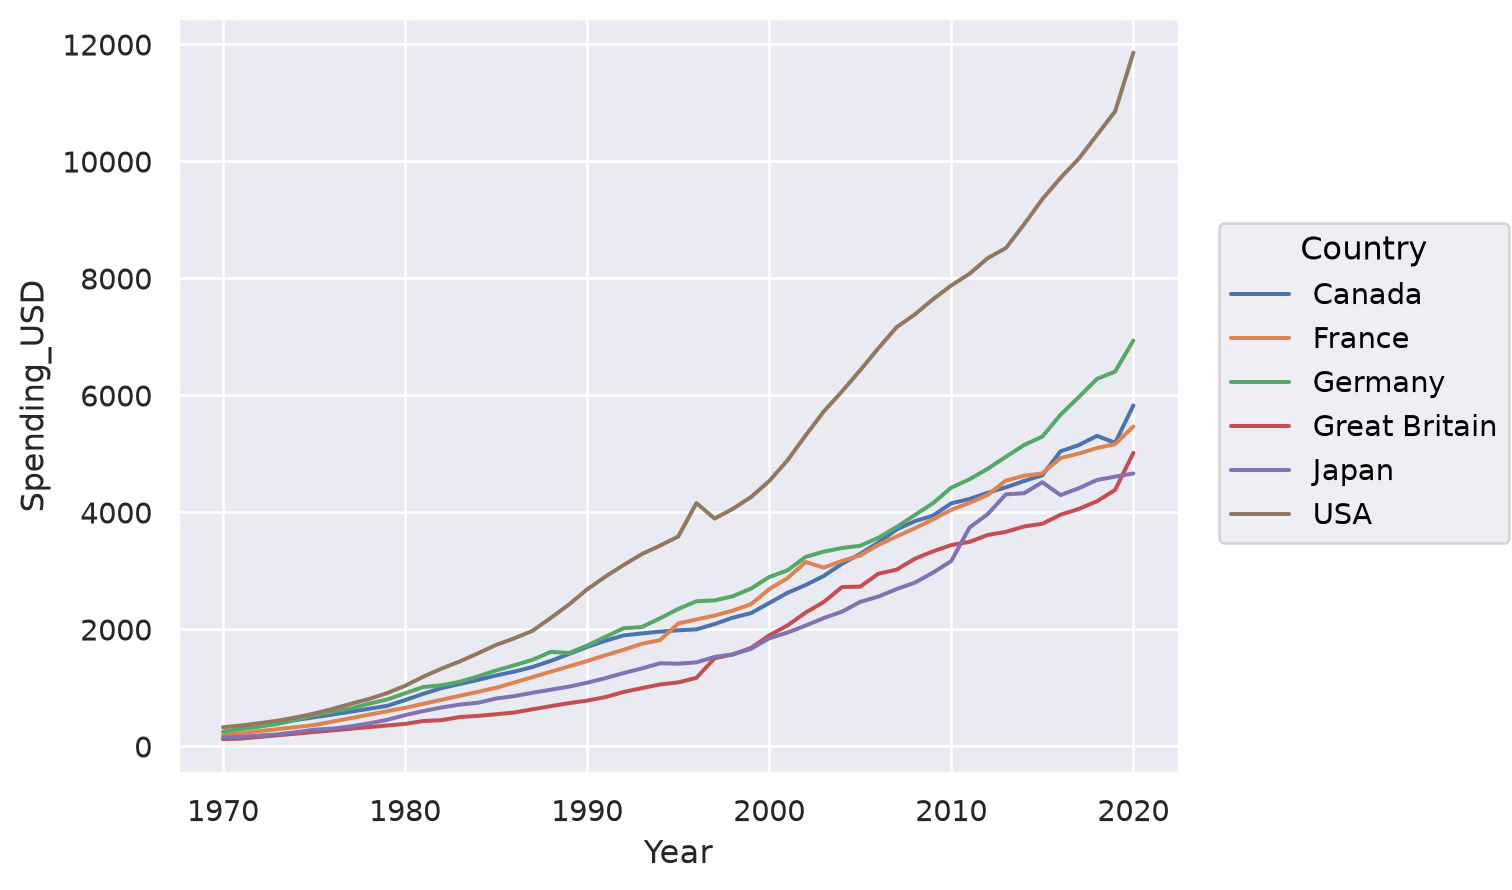

In [33]:
p.add(so.Line())   # variation 1: line plot

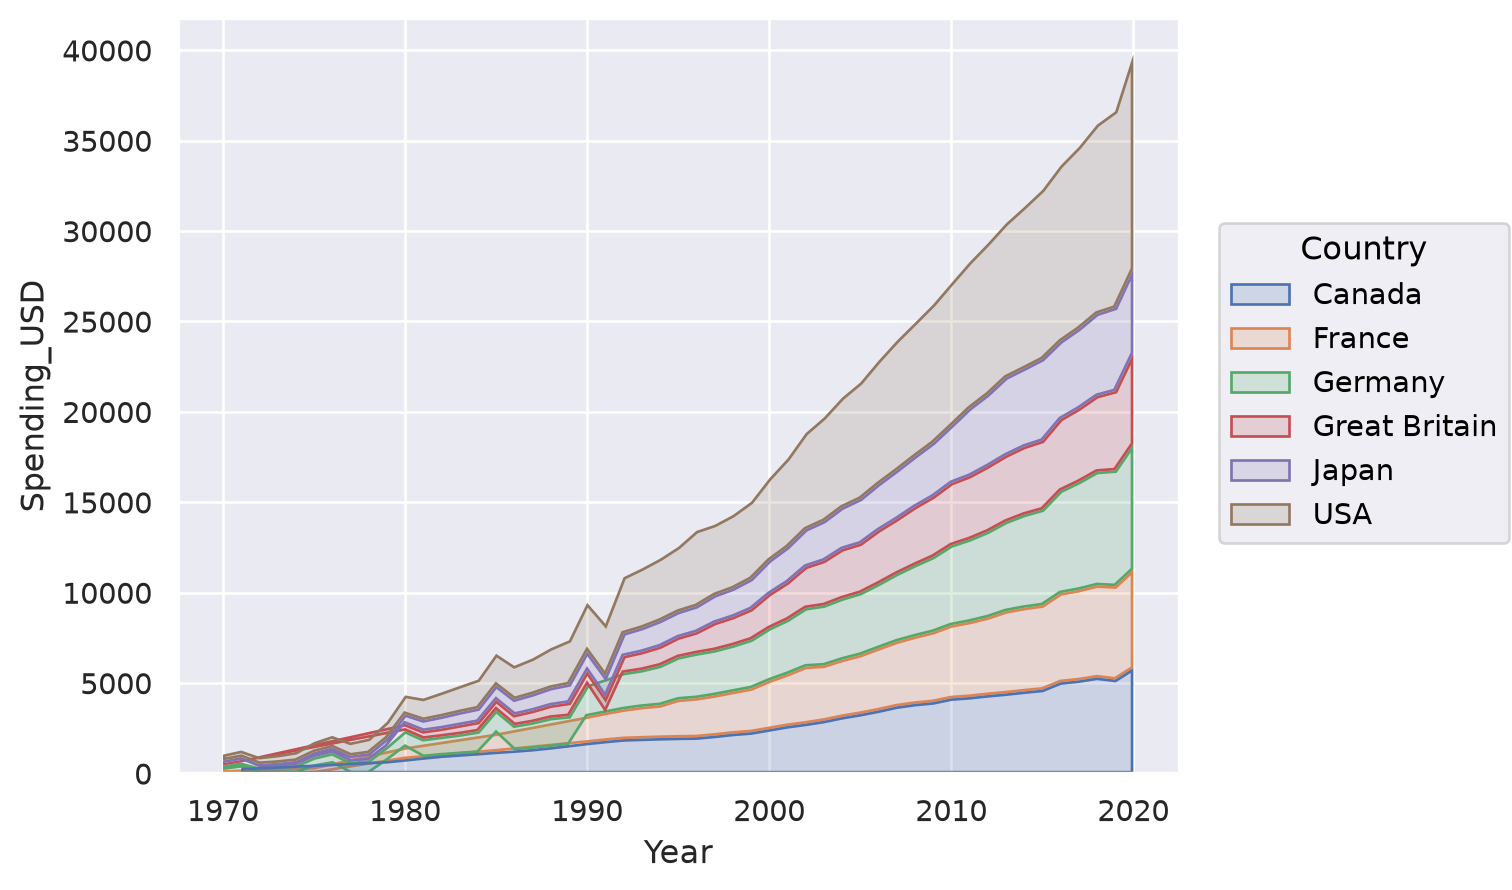

In [34]:
p.add(so.Area(), so.Stack())   # variation 2: stacked area plot (p itself is unchanged)

`Plot` is **declarative**: methods update the spec but don't draw. Rendering happens when the Plot is **displayed** (last line of a cell, or `display(p)`). Outside notebooks use `Plot.show()`; save with `Plot.save(...)`.

## Customizing the appearance

### Parameterizing scales

Data-dependent properties are controlled by a **Scale**, set with `Plot.scale`. A transform name, like matplotlib scales:

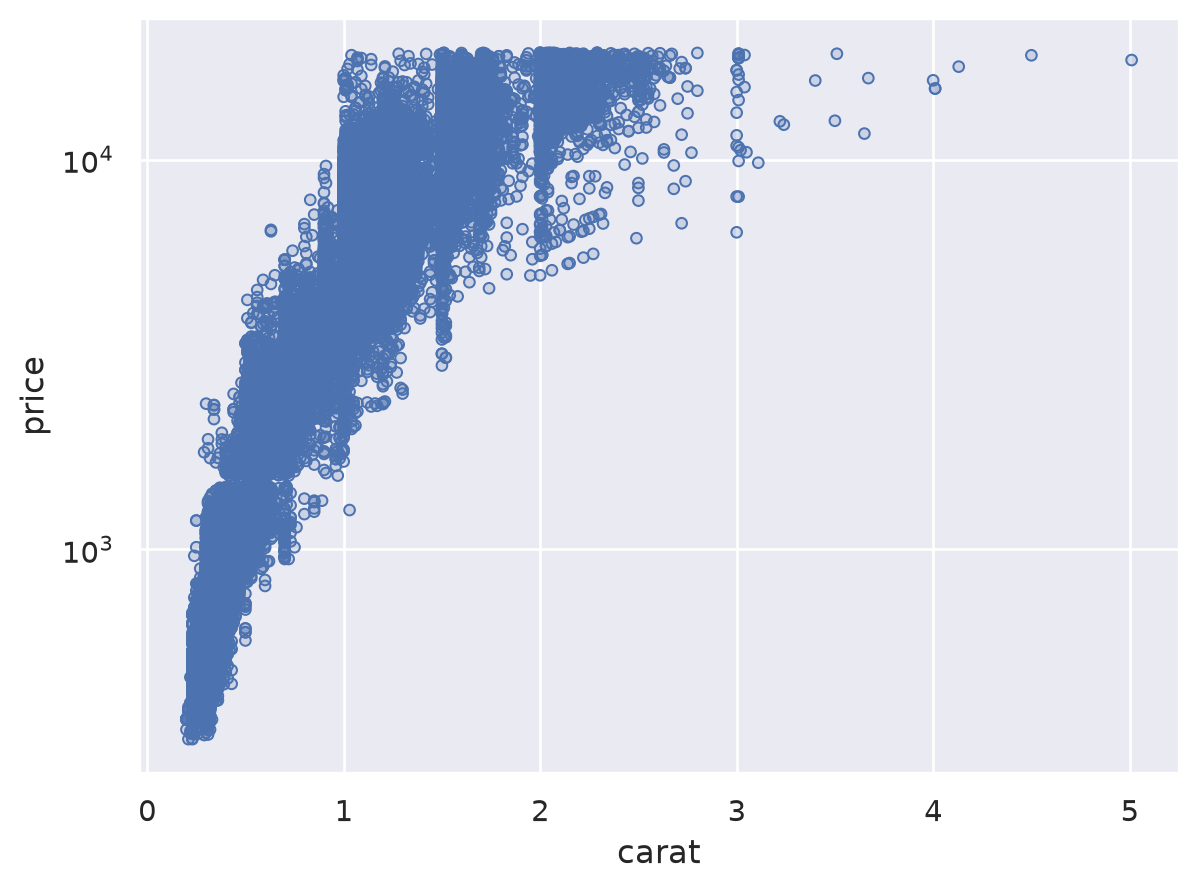

In [35]:
(
    so.Plot(diamonds, x="carat", y="price")
    .add(so.Dots())
    .scale(y="log")
)

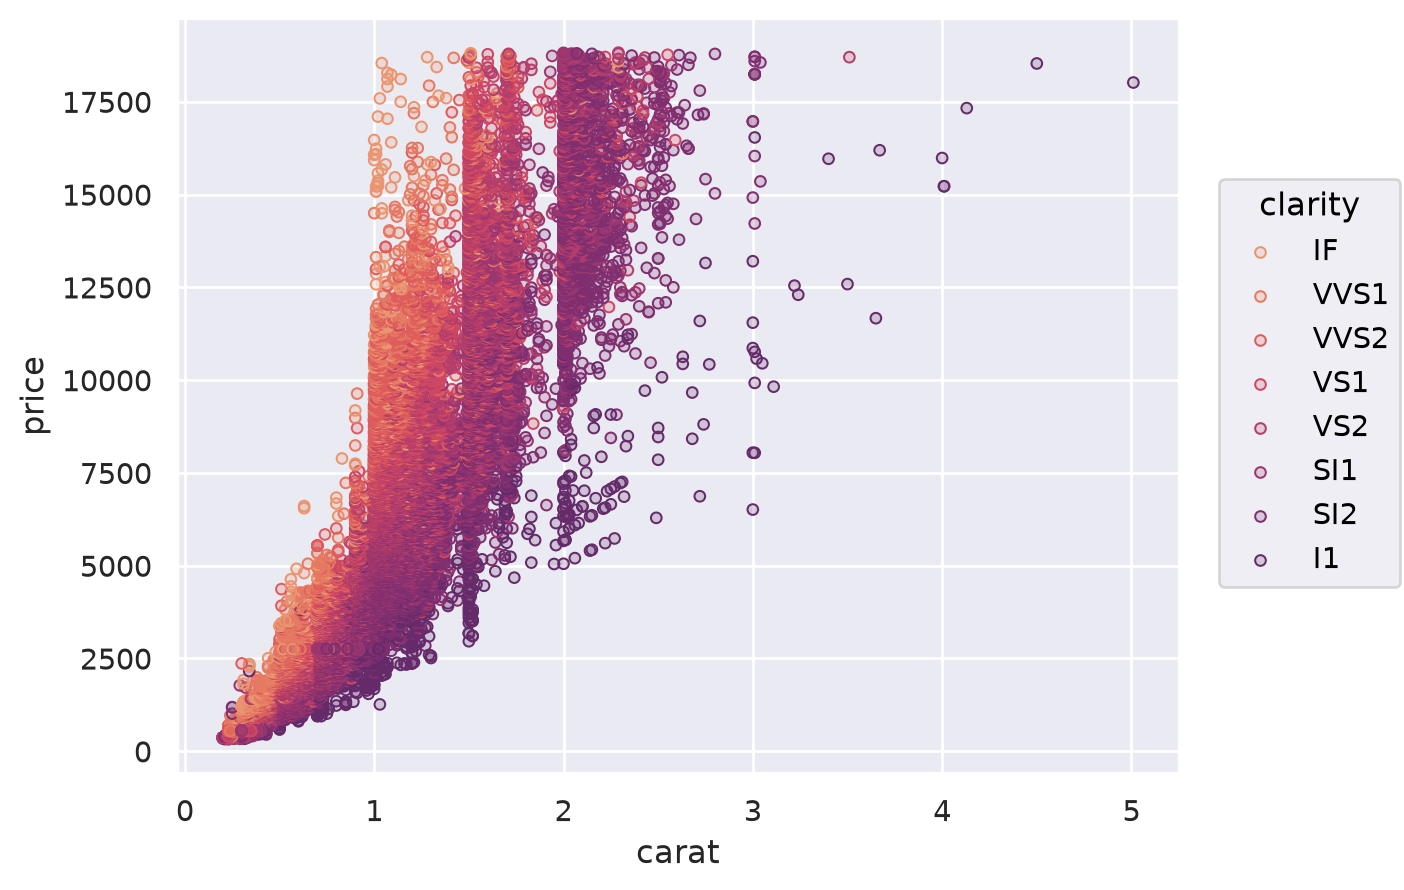

In [36]:
# For semantic properties, pass anything you'd pass to `palette=` in the function API
(
    so.Plot(diamonds, x="carat", y="price", color="clarity")
    .add(so.Dots())
    .scale(color="flare")
)

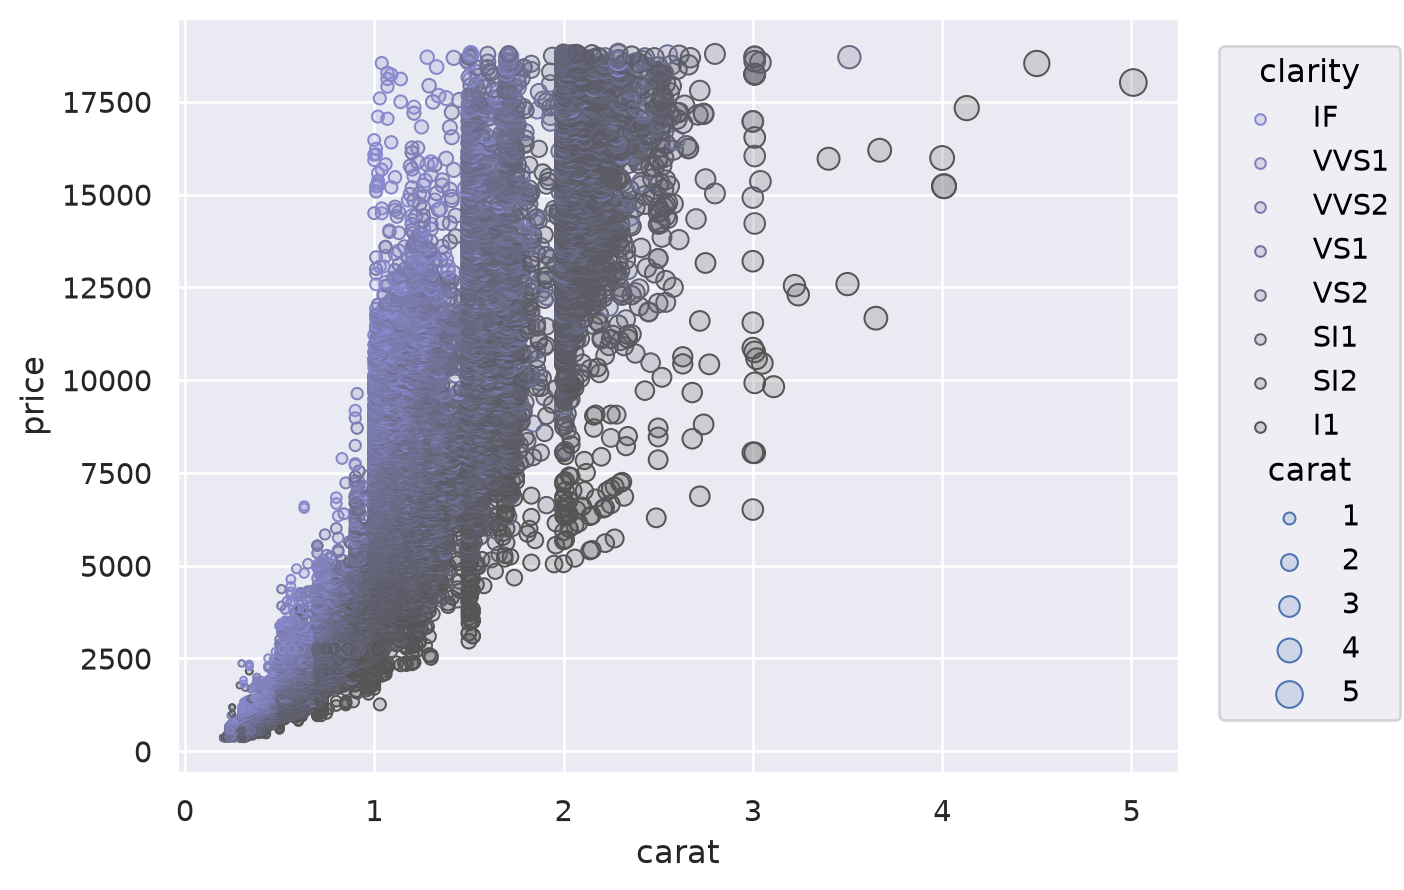

In [37]:
# A (min, max) tuple sets the output range, for numbers and for colours
(
    so.Plot(diamonds, x="carat", y="price", color="clarity", pointsize="carat")
    .add(so.Dots())
    .scale(color=("#88c", "#555"), pointsize=(2, 10))
)

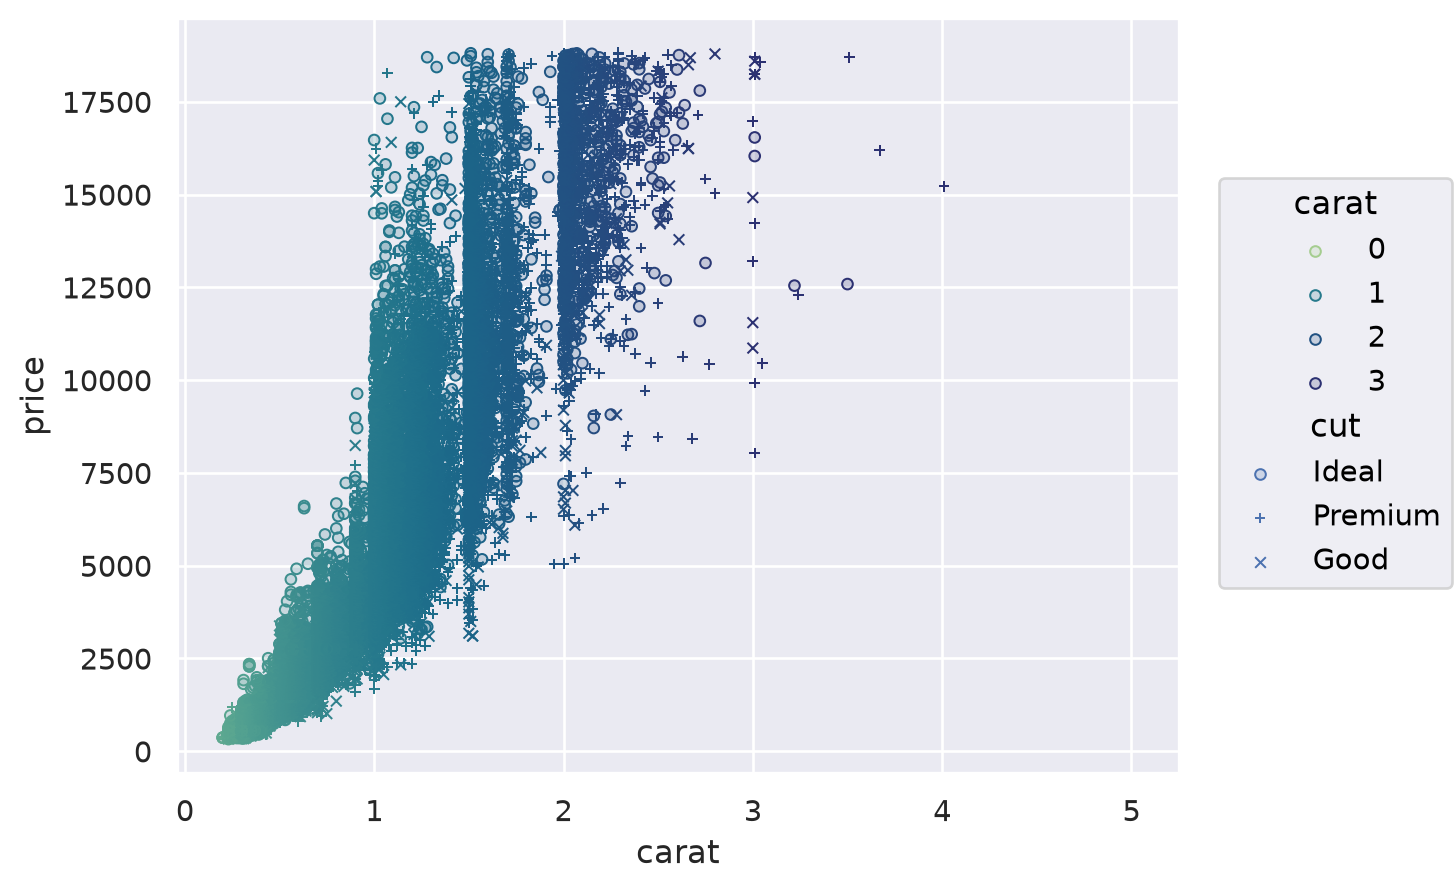

In [38]:
# Scale objects for full control: Continuous (norm, values, trans) and Nominal (ordering)
(
    so.Plot(diamonds, x="carat", y="price", color="carat", marker="cut")
    .add(so.Dots())
    .scale(
        color=so.Continuous("crest", norm=(0, 3), trans="sqrt"),
        marker=so.Nominal(["o", "+", "x"], order=["Ideal", "Premium", "Good"]),
    )
)

### Customizing legends and ticks

Scale objects also choose which values appear as ticks / legend entries (`.tick()`) and how they're formatted (`.label()`):

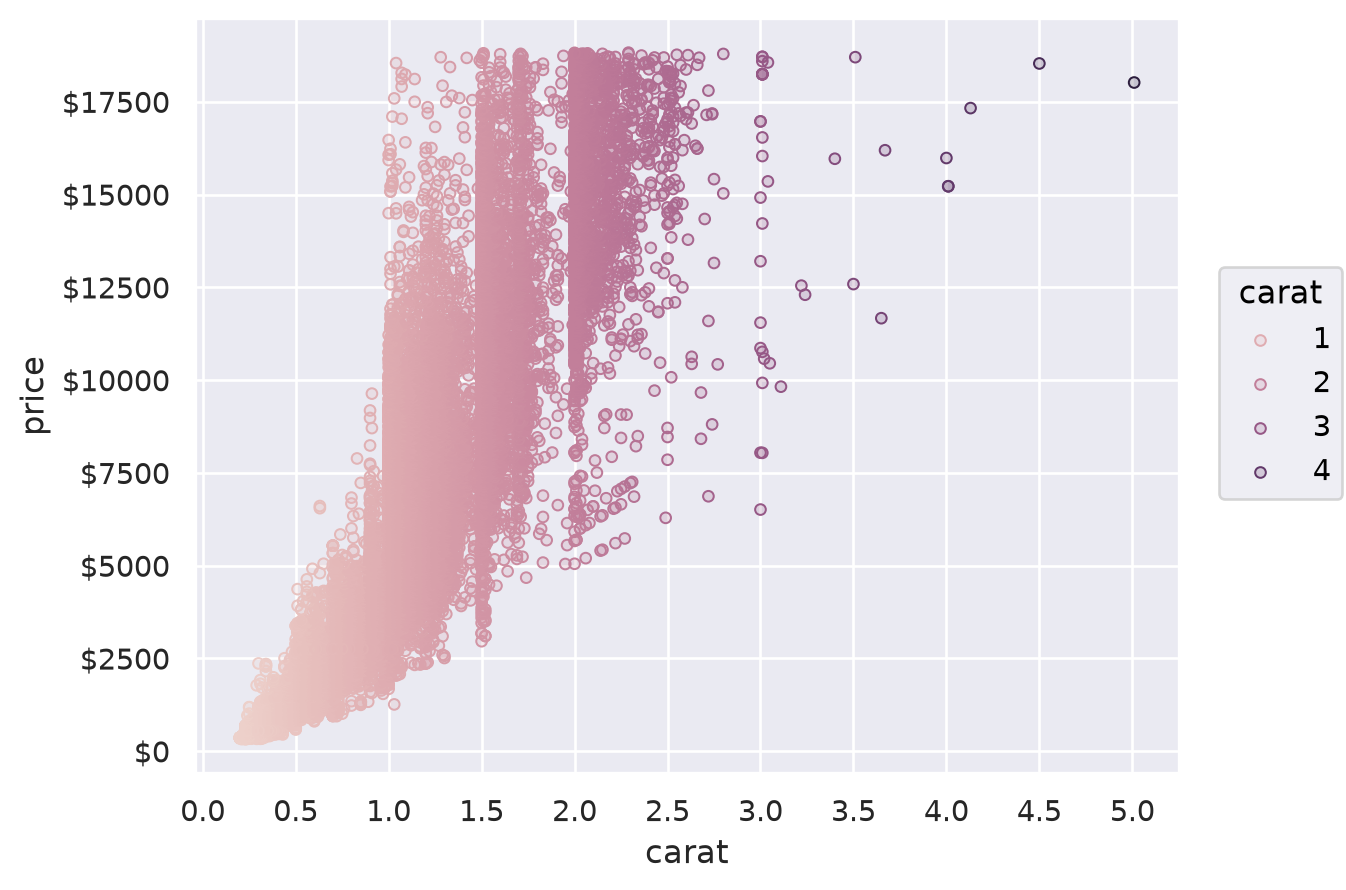

In [39]:
(
    so.Plot(diamonds, x="carat", y="price", color="carat")
    .add(so.Dots())
    .scale(
        x=so.Continuous().tick(every=0.5),              # a tick every 0.5 carat
        y=so.Continuous().label(like="${x:.0f}"),       # format y ticks as dollars
        color=so.Continuous().tick(at=[1, 2, 3, 4]),    # legend entries at these values
    )
)

### Customizing limits, labels, and titles

`Plot.label`, `Plot.limit`, `Plot.share`:

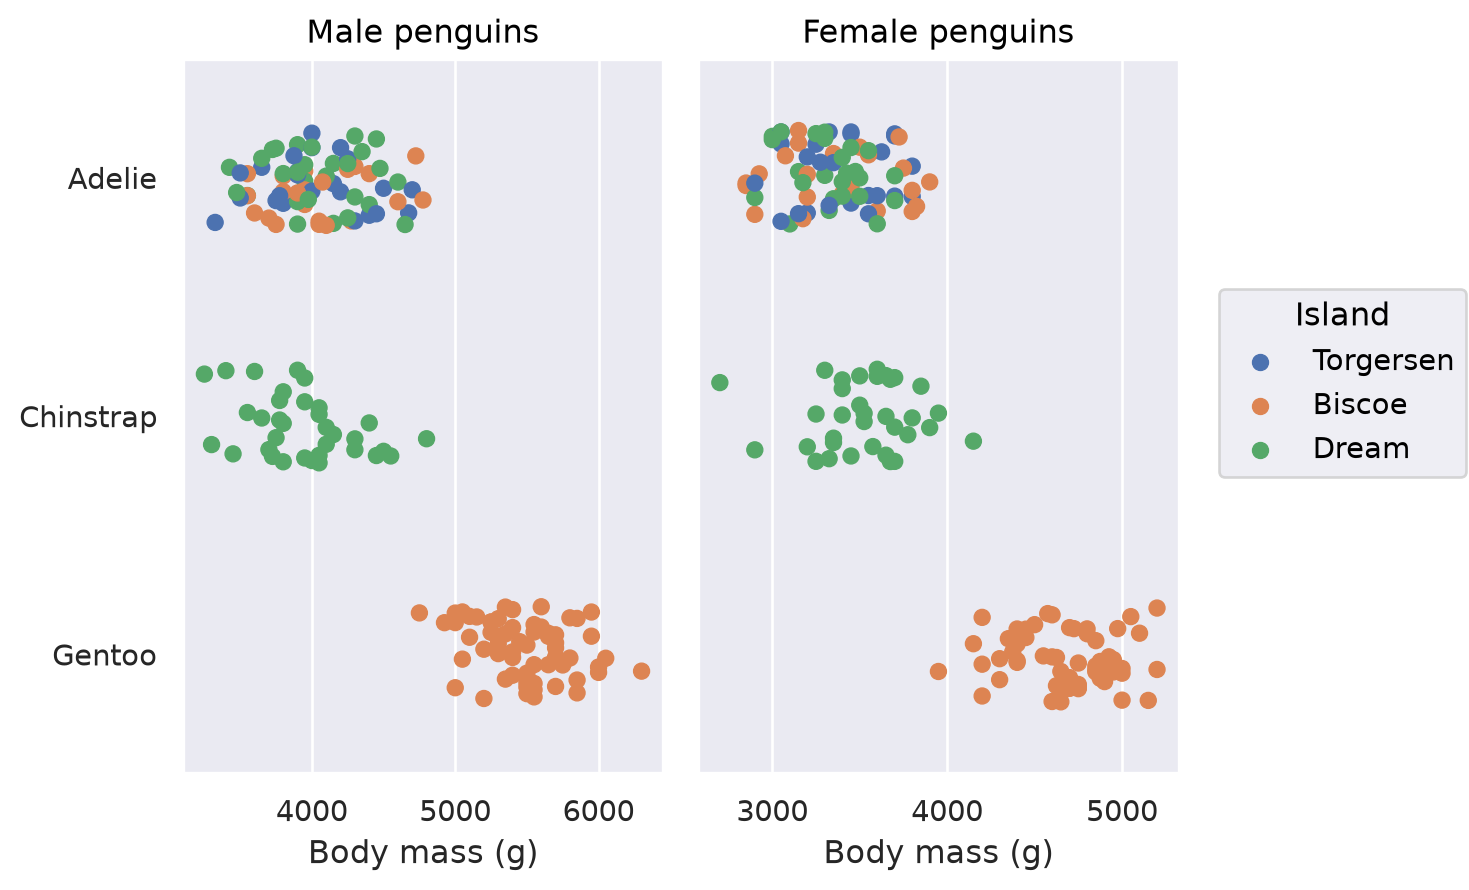

In [40]:
(
    so.Plot(penguins, x="body_mass_g", y="species", color="island")
    .facet(col="sex")
    .add(so.Dot(), so.Jitter(.5))
    .share(x=False)                    # each facet gets its own x range
    .limit(y=(2.5, -.5))               # y limits (reversed so the first species is on top)
    .label(
        x="Body mass (g)", y="",
        color=str.capitalize,          # a function applied to the legend title
        title="{} penguins".format,    # a function applied to each facet title
    )
)

### Theme customization

`Plot.theme` takes a dict of matplotlib rc parameters (you can start from seaborn's theme functions):

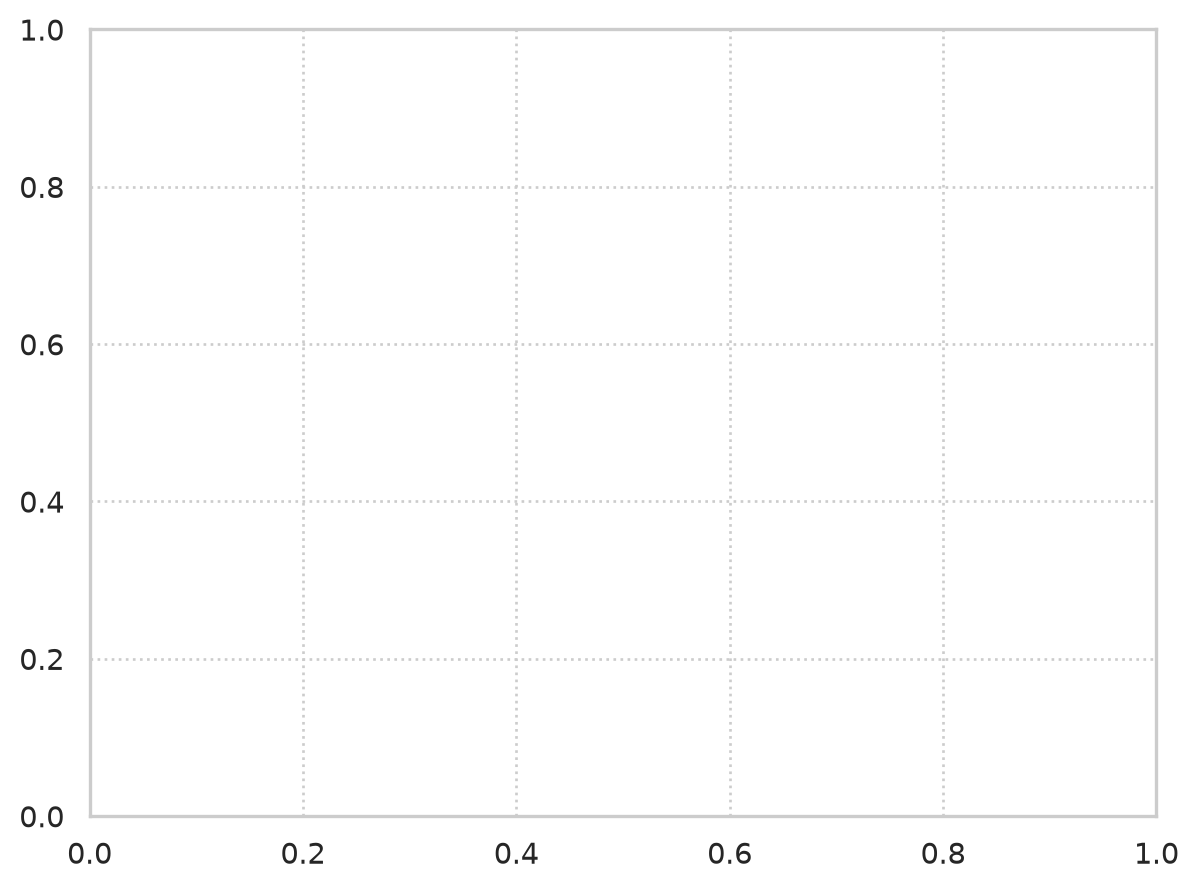

In [41]:
from seaborn import axes_style
theme_dict = {**axes_style("whitegrid"), "grid.linestyle": ":"}
so.Plot().theme(theme_dict)   # an empty plot, just to show the theme

In [42]:
# To change the theme for ALL Plot objects:
so.Plot.config.theme.update(theme_dict)

---
# Properties of Mark objects (skim)

A quick reference of the properties a Mark can have. Each can be **set** in the Mark or **mapped** in `Plot()` / `.add()`.

| Group | Properties | Notes |
| :-- | :-- | :-- |
| Coordinate | `x, y, xmin, xmax, ymin, ymax` | where the mark is drawn; `Continuous` scales can transform them (e.g. log) |
| Color | `color, fillcolor, edgecolor` | nominal → distinct hues; continuous → sequential gradient |
| | `alpha, fillalpha, edgealpha` | opacity; lower alpha shows density when points overlap |
| Style | `fill` | `True`/`False`: is the interior drawn? |
| | `marker` | string codes (`"o"`, `"s"`, `"^"`...) or `(num_sides, fill_style, angle)` |
| | `linestyle, edgestyle` | dashing pattern |
| Size | `pointsize` | diameter of dots, in points |
| | `linewidth, edgewidth, stroke` | thickness in points (stroke = for markers drawn by their outline) |
| Text | `halign, valign, fontsize, offset` | alignment, size and spacing of text marks |
| Other | `text` | content of a text mark (used literally) |
| | `group` | defines subsets for transforms without changing the look |

A few of them in action:

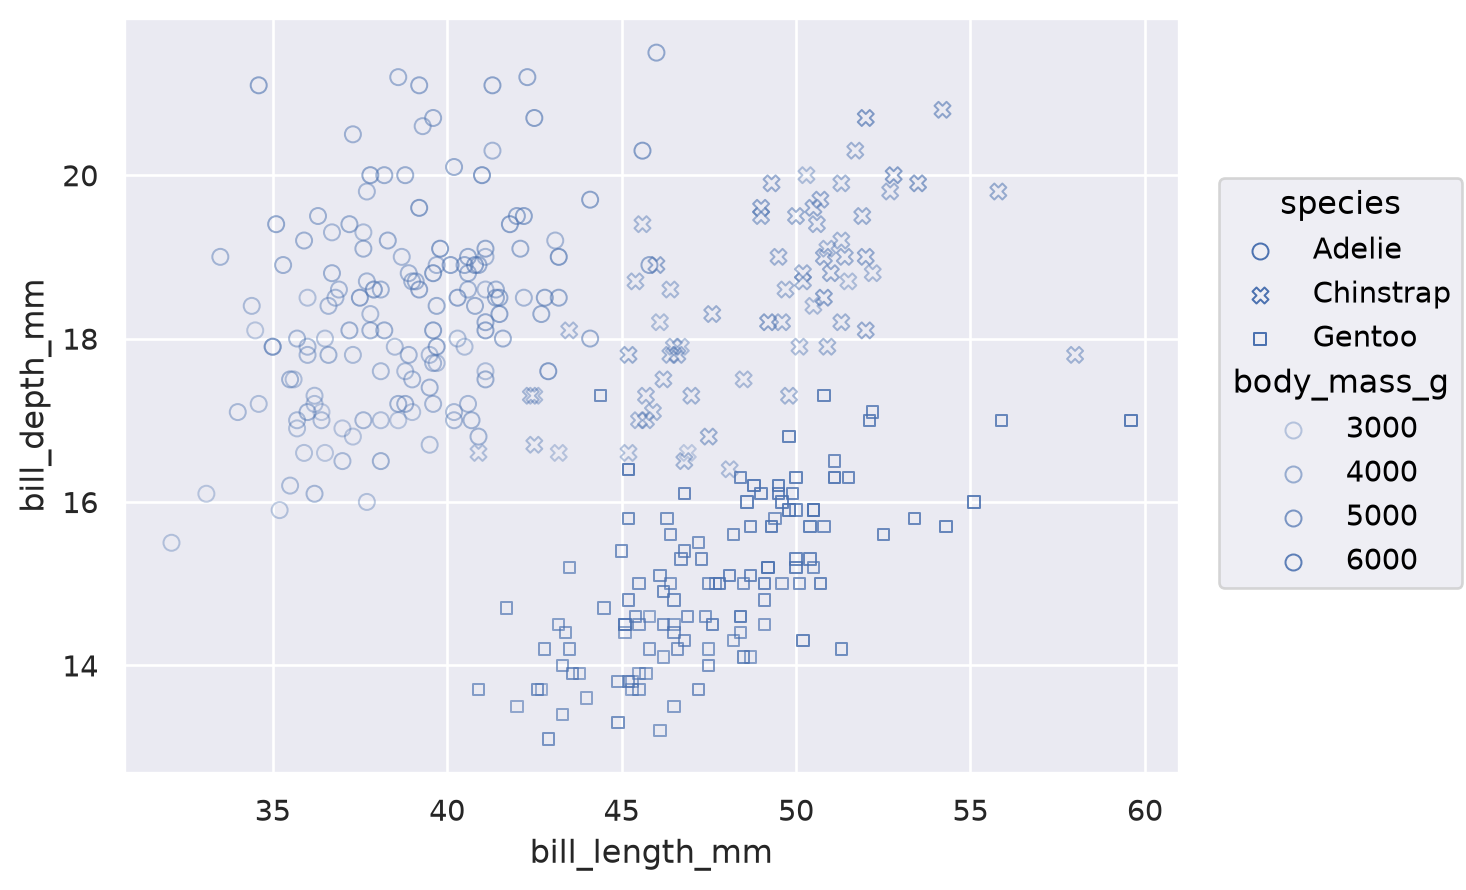

In [43]:
so.Plot.config.theme.reset()   # back to the default theme

(
    so.Plot(penguins, x="bill_length_mm", y="bill_depth_mm",
            marker="species",        # Style property, mapped
            alpha="body_mass_g")     # Color property, mapped
    .add(so.Dot(pointsize=6, edgewidth=1, fill=False))   # Size + Style properties, set directly
)

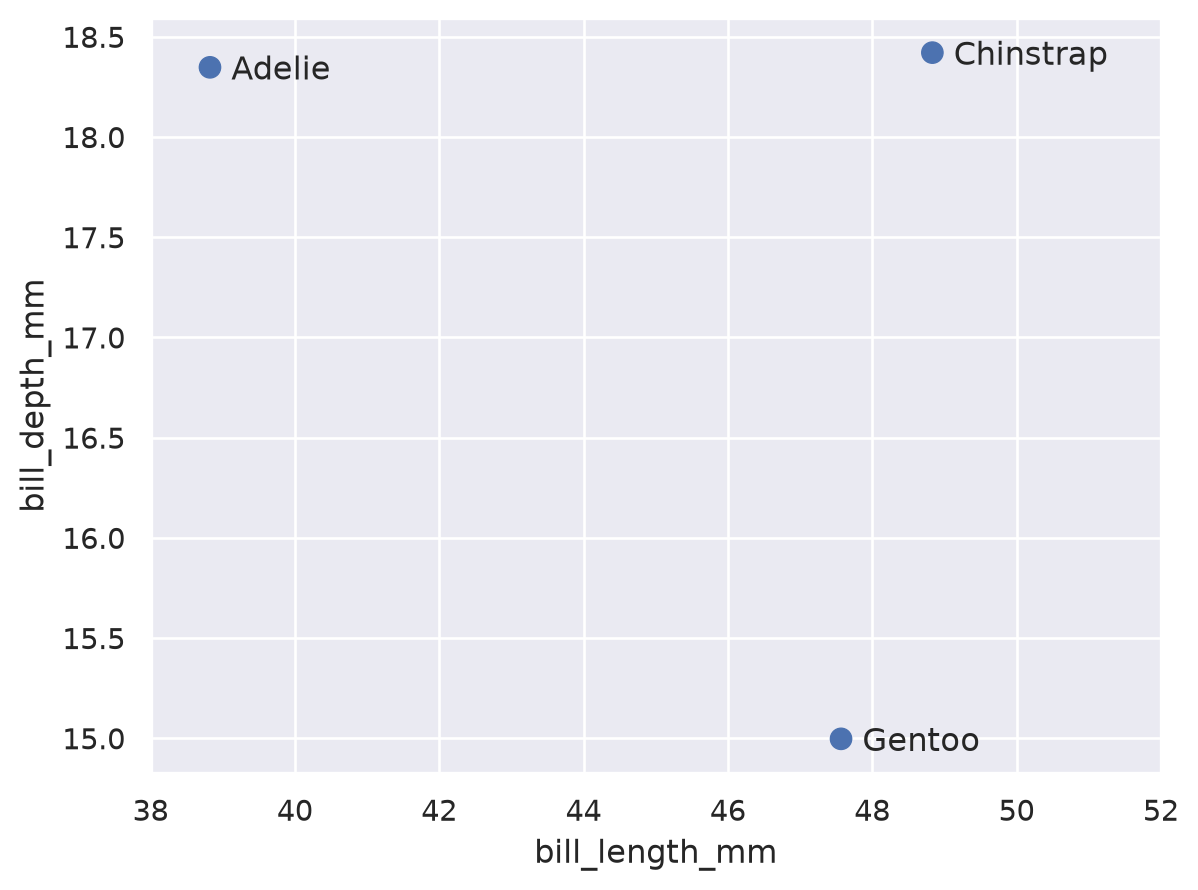

In [44]:
# Text marks: text, halign, offset, fontsize
means = penguins.groupby("species", as_index=False)[["bill_length_mm", "bill_depth_mm"]].mean()
(
    so.Plot(means, x="bill_length_mm", y="bill_depth_mm", text="species")
    .add(so.Dot(pointsize=8))
    .add(so.Text(halign="left", offset=8, fontsize=12))   # label each mean point
    .limit(x=(38, 52))                                     # extra room on the right for the labels
)

## Key takeaways

- `so.Plot(data, x=, y=, color=...)` + `.add(Mark, Stat, Move)` layers.
- **Marks** (`Dot`, `Line`, `Bar`/`Bars`, `Area`, `Text`) draw; **Stats** (`Agg`, `Hist`, `Est`, `PolyFit`) transform; **Moves** (`Dodge`, `Jitter`, `Stack`) shift positions.
- Property in the Mark = set; in `Plot()`/`.add()` = mapped.
- `.facet()`, `.pair()`, `.scale()`, `.label()`, `.limit()`, `.share()`, `.theme()`, `.on(matplotlib_obj)`.
- Methods return copies; the plot renders only when displayed.